# VideoMamba Fine-tuning on IPN Hand — Kaggle T4 ×2 (optimized)

Pipeline tối ưu cho **Kaggle T4 ×2**, **PyTorch DDP**, **FP16 AMP**, **VideoMamba-Tiny**, dữ liệu IPN Hand đọc **trực tiếp từ AVI bằng Decord**.

Các thay đổi chính:
1. Không cắt/encode hàng nghìn clip `.mp4`; đọc trực tiếp vùng `[t_start, t_end]` từ AVI.
2. Bật FP16 AMP trên T4.
3. DDP dùng `find_unused_parameters=False`, thêm barrier trước khi load best checkpoint.
4. Tự smoke-test batch 4/GPU; nếu OOM tự hạ về 2/GPU.
5. `num_workers` tự chọn theo số CPU và dùng prefetch/persistent workers.
6. Cache wheel CUDA của `causal-conv1d` và `mamba-ssm`; có thể tái dùng từ Kaggle Input.
7. Bỏ dependency `transformers` không cần thiết.

**Lưu ý:** Chạy tuần tự từ trên xuống. Notebook này tạo output mới để không auto-resume nhầm run FP32 cũ.


## CELL 1: Cấu hình, GPU và Google Drive


In [1]:
# Kaggle không mount Google Drive như Colab.
print('Run the Google Drive authentication cell next.')


Run the Google Drive authentication cell next.


In [2]:
!pip install -q PyDrive2

import glob
import json
import os

from kaggle_secrets import UserSecretsClient
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from oauth2client.service_account import ServiceAccountCredentials

# ============================================================
# Google Drive configuration
# ============================================================
# Kaggle Secrets cần có:
#   GOOGLE_SERVICE_ACCOUNT_JSON : toàn bộ Service Account JSON
#   DATASET_FILE_ID             : file ID của datasets.zip
#   WHEEL_CACHE_FOLDER_ID       : folder Google Drive dùng để lưu *.whl
#
# Folder WHEEL_CACHE_FOLDER_ID phải được Share cho Service Account
# với quyền Editor để notebook có thể upload/update wheel.
#
# Có thể dùng giá trị manual bên dưới nếu không muốn dùng Secret.
# ============================================================

DATASET_FILE_ID_MANUAL = ''
WHEEL_CACHE_FOLDER_ID_MANUAL = ''
SERVICE_ACCOUNT_JSON_PATH = ''

secrets = UserSecretsClient()


def get_kaggle_secret(label):
    try:
        value = secrets.get_secret(label)
        if value is not None and str(value).strip():
            return str(value).strip()
    except Exception as exc:
        print(
            f'[INFO] Kaggle Secret {label!r} chưa có/không attach: '
            f'{type(exc).__name__}'
        )
    return None


# ------------------------------------------------------------
# 1. Load Service Account
# ------------------------------------------------------------
service_account_json = get_kaggle_secret('GOOGLE_SERVICE_ACCOUNT_JSON')

if service_account_json:
    service_account_info = json.loads(service_account_json)
    credential_source = 'Kaggle Secret GOOGLE_SERVICE_ACCOUNT_JSON'
else:
    candidate_paths = []

    if SERVICE_ACCOUNT_JSON_PATH:
        candidate_paths.append(SERVICE_ACCOUNT_JSON_PATH)

    candidate_paths += glob.glob(
        '/kaggle/input/**/service_account.json',
        recursive=True
    )
    candidate_paths += glob.glob(
        '/kaggle/input/**/service-account.json',
        recursive=True
    )

    candidate_paths = sorted({
        p for p in candidate_paths
        if os.path.isfile(p)
    })

    if len(candidate_paths) != 1:
        raise RuntimeError(
            'Cần đúng một Service Account JSON hoặc '
            'Secret GOOGLE_SERVICE_ACCOUNT_JSON.'
        )

    with open(candidate_paths[0], 'r', encoding='utf-8') as f:
        service_account_info = json.load(f)

    credential_source = candidate_paths[0]


required_keys = {'client_email', 'private_key', 'token_uri'}
missing_keys = required_keys.difference(service_account_info)

if missing_keys:
    raise KeyError(
        f'Service Account JSON thiếu: {sorted(missing_keys)}'
    )


# ------------------------------------------------------------
# 2. Load Drive IDs
# ------------------------------------------------------------
DATASET_FILE_ID = (
    get_kaggle_secret('DATASET_FILE_ID')
    or DATASET_FILE_ID_MANUAL.strip()
)

WHEEL_CACHE_FOLDER_ID = (
    get_kaggle_secret('WHEEL_CACHE_FOLDER_ID')
    or WHEEL_CACHE_FOLDER_ID_MANUAL.strip()
)

if not DATASET_FILE_ID:
    raise RuntimeError(
        'Thiếu DATASET_FILE_ID.'
    )

if not WHEEL_CACHE_FOLDER_ID:
    raise RuntimeError(
        'Thiếu WHEEL_CACHE_FOLDER_ID. '
        'Tạo một folder Google Drive, share cho Service Account '
        'với quyền Editor, rồi lưu Folder ID vào Kaggle Secret '
        'WHEEL_CACHE_FOLDER_ID.'
    )


# ------------------------------------------------------------
# 3. Authenticate with READ + WRITE permission
# ------------------------------------------------------------
credentials = ServiceAccountCredentials.from_json_keyfile_dict(
    service_account_info,
    ['https://www.googleapis.com/auth/drive']
)

gauth = GoogleAuth()
gauth.credentials = credentials
drive = GoogleDrive(gauth)


# ------------------------------------------------------------
# 4. Verify wheel-cache folder is accessible
# ------------------------------------------------------------
try:
    wheel_cache_folder = drive.CreateFile({
        'id': WHEEL_CACHE_FOLDER_ID
    })
    wheel_cache_folder.FetchMetadata(
        fields='id,title,mimeType,labels'
    )
    
    labels = wheel_cache_folder.get('labels', {})
    
    if labels.get('trashed', False):
        raise RuntimeError(
            'WHEEL_CACHE_FOLDER_ID đang trỏ tới folder trong Trash.'
        )

    if (
        wheel_cache_folder.get('mimeType')
        != 'application/vnd.google-apps.folder'
    ):
        raise RuntimeError(
            'WHEEL_CACHE_FOLDER_ID không trỏ tới Google Drive folder.'
        )

except Exception as exc:
    raise RuntimeError(
        'Không truy cập được WHEEL_CACHE_FOLDER_ID. '
        'Kiểm tra Folder ID và đảm bảo folder đã được Share cho '
        'Service Account với quyền Editor.'
    ) from exc


print('[OK] Google Drive connected with read/write permission.')
print('Credential source:', credential_source)
print('Service account:', service_account_info['client_email'])
print('Dataset file ID loaded:', bool(DATASET_FILE_ID))
print(
    'Wheel cache folder:',
    wheel_cache_folder.get('title', WHEEL_CACHE_FOLDER_ID)
)


[OK] Google Drive connected with read/write permission.
Credential source: Kaggle Secret GOOGLE_SERVICE_ACCOUNT_JSON
Service account: kaggle@gmail-api-project-502006.iam.gserviceaccount.com
Dataset file ID loaded: True
Wheel cache folder: wheel_cache


In [3]:
!nvidia-smi

import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

WORK_ROOT = '/kaggle/working'
DATA_ROOT = os.path.join(WORK_ROOT, 'ipn_hand_data')
REPO_DIR = os.path.join(WORK_ROOT, 'VideoMamba')
CHECKPOINT_PATH = os.path.join(WORK_ROOT, 'checkpoints', 'videomamba_t16_in1k.pth')

# ============================================================
# Main training configuration
# ============================================================

RUN_NAME = 'videomamba_ipn_direct_224_ddp2_fp32_v2'
OUTPUT_DIR = os.path.join(WORK_ROOT, RUN_NAME)

DDP_GPUS = 2

TRAIN_BATCH_SIZE = 2
UPDATE_FREQ = 2

CPU_COUNT = os.cpu_count() or 2
NUM_WORKERS_PER_RANK = max(
    1,
    min(2, CPU_COUNT // DDP_GPUS)
)

EFFECTIVE_BATCH_SIZE = (
    TRAIN_BATCH_SIZE
    * DDP_GPUS
    * UPDATE_FREQ
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

assert EFFECTIVE_BATCH_SIZE == 8

print('[OK] Training configuration')
print(f'Precision               : FP32')
print(f'GPUs                    : {DDP_GPUS}')
print(f'Batch / GPU             : {TRAIN_BATCH_SIZE}')
print(f'Update frequency        : {UPDATE_FREQ}')
print(f'Effective batch size    : {EFFECTIVE_BATCH_SIZE}')
print(f'Workers / rank          : {NUM_WORKERS_PER_RANK}')
print(f'Output directory        : {OUTPUT_DIR}')

print(f'[OK] DDP: 2 ranks -> cuda:0, cuda:1')
print(f'CPU_COUNT={CPU_COUNT} | NUM_WORKERS_PER_RANK={NUM_WORKERS_PER_RANK}')
print(f'Initial TRAIN_BATCH_SIZE/GPU={TRAIN_BATCH_SIZE}')
print('OUTPUT_DIR:', OUTPUT_DIR)


Mon Aug 17 19:55:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## CELL 2: Tải, giải nén và kiểm tra dataset (có cache marker)


In [4]:
import glob
import json
import os
import shutil
import zipfile

archive_local = '/kaggle/working/datasets.zip'
download_marker = '/kaggle/working/datasets_source.json'
extract_marker = os.path.join(DATA_ROOT, '.extract_ok.json')

# Nếu đổi DATASET_FILE_ID trong cùng session, không dùng nhầm ZIP cũ.
current_source = None
if os.path.isfile(download_marker):
    try:
        current_source = json.load(open(download_marker, 'r', encoding='utf-8'))
    except Exception:
        current_source = None

need_download = (
    not os.path.isfile(archive_local)
    or not current_source
    or current_source.get('file_id') != DATASET_FILE_ID
)

if need_download:
    if os.path.isfile(archive_local):
        os.remove(archive_local)
    dataset_file = drive.CreateFile({'id': DATASET_FILE_ID})
    dataset_file.GetContentFile(archive_local)
    with open(download_marker, 'w', encoding='utf-8') as f:
        json.dump({'file_id': DATASET_FILE_ID}, f)
    print('[OK] Dataset ZIP downloaded.')
else:
    print('[CACHE] Reusing downloaded datasets.zip')

if not os.path.isfile(archive_local) or os.path.getsize(archive_local) == 0:
    raise FileNotFoundError('datasets.zip download failed.')

archive_signature = {
    'file_id': DATASET_FILE_ID,
    'size': os.path.getsize(archive_local),
}

extract_state = None
if os.path.isfile(extract_marker):
    try:
        extract_state = json.load(open(extract_marker, 'r', encoding='utf-8'))
    except Exception:
        extract_state = None

labels_path = os.path.join(DATA_ROOT, 'labels.txt')
video_dir = os.path.join(DATA_ROOT, 'videos02', 'videos')
can_reuse_extract = (
    extract_state == archive_signature
    and os.path.isfile(labels_path)
    and os.path.isdir(video_dir)
)

if not can_reuse_extract:
    # Tránh trộn dataset cũ/mới khi đổi ZIP.
    if os.path.isdir(DATA_ROOT):
        shutil.rmtree(DATA_ROOT)
    os.makedirs(DATA_ROOT, exist_ok=True)

    with zipfile.ZipFile(archive_local, 'r') as zf:
        zf.extractall(DATA_ROOT)

    labels_path = os.path.join(DATA_ROOT, 'labels.txt')
    if not os.path.isfile(labels_path):
        nested_labels = glob.glob(os.path.join(DATA_ROOT, '*', 'labels.txt'))
        if len(nested_labels) != 1:
            raise FileNotFoundError(f'Cannot locate unique labels.txt: {nested_labels}')
        nested_root = os.path.dirname(nested_labels[0])
        for item in os.listdir(nested_root):
            src_item = os.path.join(nested_root, item)
            dst_item = os.path.join(DATA_ROOT, item)
            if os.path.exists(dst_item):
                raise FileExistsError(dst_item)
            shutil.move(src_item, dst_item)
        os.rmdir(nested_root)

    with open(extract_marker, 'w', encoding='utf-8') as f:
        json.dump(archive_signature, f)
    print('[OK] Dataset extracted.')
else:
    print('[CACHE] Reusing extracted dataset.')

# Tự tìm toàn bộ file AVI bên trong DATA_ROOT
raw_videos = sorted(glob.glob(
    os.path.join(DATA_ROOT, "**", "*.avi"),
    recursive=True
))

# Tự tìm labels.txt
labels_candidates = sorted(glob.glob(
    os.path.join(DATA_ROOT, "**", "labels.txt"),
    recursive=True
))

if not raw_videos:
    raise FileNotFoundError(
        f"No AVI files found anywhere under {DATA_ROOT}"
    )

if len(labels_candidates) != 1:
    raise RuntimeError(
        f"Expected exactly one labels.txt, found: {labels_candidates}"
    )

labels_path = labels_candidates[0]

# Xác định thư mục chứa AVI
video_dirs = sorted({
    os.path.dirname(p)
    for p in raw_videos
})

if len(video_dirs) != 1:
    raise RuntimeError(
        f"AVI files are in multiple directories: {video_dirs}"
    )

video_dir = video_dirs[0]

print("[OK] video_dir:", video_dir)
print("[OK] labels_path:", labels_path)
print("[OK] raw videos:", len(raw_videos))

print(f'Archive size: {os.path.getsize(archive_local)/2**30:.2f} GB')
print(f'Raw videos: {len(raw_videos)}')
with open(labels_path, 'r', encoding='utf-8', errors='replace') as f:
    for _ in range(5):
        line = f.readline()
        if not line:
            break
        print(line.rstrip())


[OK] Dataset ZIP downloaded.
[OK] Dataset extracted.
[OK] video_dir: /kaggle/working/ipn_hand_data/videos
[OK] labels_path: /kaggle/working/ipn_hand_data/labels.txt
[OK] raw videos: 200
Archive size: 4.60 GB
Raw videos: 200
video,label,id,t_start,t_end,frames
1CM1_4_R_#229,D0X,1,1,17,17
1CM1_4_R_#229,G11,14,18,55,38
1CM1_4_R_#229,B0B,3,56,284,229
1CM1_4_R_#229,G04,7,285,308,24


## CELL 3: Clone VideoMamba và cài CUDA extensions với Google Drive wheel cache


* Add input --> thêm dataset --> kiểm tra xem đã thêm wheel_cache chưa

In [5]:
!ls -lh /kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels
import glob

causal = glob.glob(
    "/kaggle/input/**/causal_conv1d*.whl",
    recursive=True
)

mamba = glob.glob(
    "/kaggle/input/**/mamba_ssm*.whl",
    recursive=True
)

print("causal_conv1d:")
print(causal)

print("\nmamba_ssm:")
print(mamba)



total 53M
-rw-r--r-- 1 nobody nogroup 5.1M Aug 17 18:07 causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl
-rw-r--r-- 1 nobody nogroup  48M Aug 17 18:08 mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl
causal_conv1d:
['/kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels/causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl']

mamba_ssm:
['/kaggle/input/datasets/hoanganh94/videomamba-t4-cuda-wheels/mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl']


In [6]:
# ============================================================
# CELL 3
# VideoMamba environment setup using prebuilt CUDA wheels
#
# - NO CUDA compilation
# - NO Google Drive cache
# - Load wheels directly from Private Kaggle Dataset
# - Pin transformers version required by mamba_ssm 1.0.1
# ============================================================

%cd /kaggle/working

import glob
import importlib
import inspect
import os
import subprocess
import sys

from datetime import datetime
from pathlib import Path

import torch


# ============================================================
# 0. CONFIG
# ============================================================

REPO_DIR = "/kaggle/working/VideoMamba"

REPO_COMMIT = (
    "37355c26d0ae99ca2459f6d4044a5f509031a79f"
)

WHEEL_DATASET_NAME = (
    "hoanganh94/videomamba-t4-cuda-wheels"
)


# ============================================================
# Logging helper
# ============================================================

def log(message):
    now = datetime.now().strftime("%H:%M:%S")

    print(
        f"[{now}] {message}",
        flush=True
    )


# ============================================================
# Subprocess helper with realtime output
# ============================================================

def run_stream(
    command,
    *,
    label=None,
    check=True
):

    if label:
        print()
        print("=" * 70)
        log(label)
        print("=" * 70)

    log(
        "CMD: "
        + " ".join(str(x) for x in command)
    )

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    assert process.stdout is not None

    for line in iter(
        process.stdout.readline,
        ""
    ):
        print(
            line,
            end="",
            flush=True
        )

    process.stdout.close()

    return_code = process.wait()

    if check and return_code != 0:

        raise RuntimeError(
            f"Command failed with exit code {return_code}:\n"
            + " ".join(str(x) for x in command)
        )

    return return_code


# ============================================================
# STEP 1/6
# Validate Kaggle runtime
# ============================================================

log("STEP 1/6 - Checking Kaggle runtime")


print(
    f"[INFO] Python: "
    f"{sys.version_info.major}."
    f"{sys.version_info.minor}."
    f"{sys.version_info.micro}"
)

print(
    f"[INFO] PyTorch: {torch.__version__}"
)

print(
    f"[INFO] PyTorch CUDA: {torch.version.cuda}"
)

print(
    f"[INFO] CUDA available: "
    f"{torch.cuda.is_available()}"
)


# Wheels were built for CPython 3.12
if sys.version_info[:2] != (3, 12):

    raise RuntimeError(
        "The cached CUDA wheels were built for CPython 3.12, "
        f"but the current runtime uses Python "
        f"{sys.version_info.major}.{sys.version_info.minor}."
    )


if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA is not available. "
        "Enable GPU T4 x2 in Kaggle."
    )


gpu_count = torch.cuda.device_count()

print(
    f"[INFO] CUDA devices: {gpu_count}"
)


for gpu_id in range(gpu_count):

    gpu_name = torch.cuda.get_device_name(
        gpu_id
    )

    capability = torch.cuda.get_device_capability(
        gpu_id
    )

    print(
        f"[INFO] cuda:{gpu_id} -> "
        f"{gpu_name} | "
        f"compute capability="
        f"{capability[0]}.{capability[1]}"
    )


# Wheels were compiled specifically for sm_75
for gpu_id in range(gpu_count):

    capability = torch.cuda.get_device_capability(
        gpu_id
    )

    if capability != (7, 5):

        raise RuntimeError(
            f"cuda:{gpu_id} has compute capability "
            f"{capability}, but cached wheels were "
            f"compiled for sm_75 (Tesla T4)."
        )


log("[OK] Runtime is compatible with cached T4 wheels.")


# ============================================================
# STEP 2/6
# Prepare VideoMamba repository
# ============================================================

log("STEP 2/6 - Preparing VideoMamba repository")


if not os.path.isdir(REPO_DIR):

    run_stream(
        [
            "git",
            "clone",
            "https://github.com/OpenGVLab/VideoMamba.git",
            REPO_DIR
        ],
        label="Cloning VideoMamba"
    )

else:

    log(
        f"Repository already exists: {REPO_DIR}"
    )


current_commit = subprocess.check_output(
    [
        "git",
        "-C",
        REPO_DIR,
        "rev-parse",
        "HEAD"
    ],
    text=True
).strip()


if current_commit != REPO_COMMIT:

    run_stream(
        [
            "git",
            "-C",
            REPO_DIR,
            "fetch",
            "--depth",
            "1",
            "origin",
            REPO_COMMIT
        ],
        label="Fetching pinned VideoMamba commit"
    )


run_stream(
    [
        "git",
        "-C",
        REPO_DIR,
        "checkout",
        "--force",
        REPO_COMMIT
    ],
    label="Checking out pinned commit"
)


log(
    f"[OK] VideoMamba commit: "
    f"{REPO_COMMIT[:8]}"
)


# ============================================================
# STEP 3/6
# Install Python dependencies
# ============================================================

log("STEP 3/6 - Preparing Python dependencies")


# ------------------------------------------------------------
# sentence-transformers from the default Kaggle environment
# requires transformers >= 4.41.
#
# VideoMamba does NOT use sentence-transformers.
#
# mamba_ssm 1.0.1 uses an older Transformers generation API,
# therefore we remove sentence-transformers and pin
# transformers==4.36.1.
# ------------------------------------------------------------

run_stream(
    [
        sys.executable,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "sentence-transformers"
    ],
    label="Removing incompatible sentence-transformers",
    check=False
)


run_stream(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--disable-pip-version-check",

        "decord==0.6.0",
        "timm==0.4.12",
        "einops==0.7.0",

        # Required for mamba_ssm 1.0.1
        "transformers==4.36.1",

        "tensorboardX",
        "pandas",
        "scikit-learn",
        "tqdm",
        "packaging",
        "ninja",
        "seaborn"
    ],
    label="Installing Python dependencies"
)


# ============================================================
# STEP 4/6
# Find prebuilt CUDA wheels from Kaggle Input
# ============================================================

log(
    "STEP 4/6 - Searching for prebuilt CUDA wheels"
)


causal_candidates = sorted(
    glob.glob(
        "/kaggle/input/**/causal_conv1d*.whl",
        recursive=True
    )
)


mamba_candidates = sorted(
    glob.glob(
        "/kaggle/input/**/mamba_ssm*.whl",
        recursive=True
    )
)


print()
print("causal_conv1d wheel candidates:")

for path in causal_candidates:
    print(
        "  ",
        path
    )


print()
print("mamba_ssm wheel candidates:")

for path in mamba_candidates:
    print(
        "  ",
        path
    )


if not causal_candidates:

    raise FileNotFoundError(
        "causal_conv1d wheel was not found under "
        "/kaggle/input.\n"
        "Attach the Private Kaggle Dataset:\n"
        f"{WHEEL_DATASET_NAME}"
    )


if not mamba_candidates:

    raise FileNotFoundError(
        "mamba_ssm wheel was not found under "
        "/kaggle/input.\n"
        "Attach the Private Kaggle Dataset:\n"
        f"{WHEEL_DATASET_NAME}"
    )


# ============================================================
# Prefer wheels from our own Private Kaggle Dataset
# ============================================================

def choose_wheel(
    candidates,
    package_name
):

    # Current Kaggle mount style:
    #
    # /kaggle/input/datasets/
    #     hoanganh94/
    #     videomamba-t4-cuda-wheels/
    #     xxx.whl

    preferred = [
        path
        for path in candidates
        if (
            "hoanganh94"
            in path
            and
            "videomamba-t4-cuda-wheels"
            in path
        )
    ]


    if len(preferred) == 1:

        return preferred[0]


    if len(preferred) > 1:

        raise RuntimeError(
            f"Multiple preferred {package_name} wheels found:\n"
            + "\n".join(preferred)
        )


    if len(candidates) == 1:

        return candidates[0]


    raise RuntimeError(
        f"Multiple {package_name} wheel candidates found "
        "and no unique preferred wheel could be selected:\n"
        + "\n".join(candidates)
    )


causal_wheel = choose_wheel(
    causal_candidates,
    "causal_conv1d"
)


mamba_wheel = choose_wheel(
    mamba_candidates,
    "mamba_ssm"
)


print()

log(
    f"[OK] Selected causal_conv1d:\n"
    f"     {causal_wheel}"
)

log(
    f"[OK] Selected mamba_ssm:\n"
    f"     {mamba_wheel}"
)


# ============================================================
# STEP 5/6
# Install cached CUDA wheels
# ============================================================

log(
    "STEP 5/6 - Installing prebuilt CUDA wheels"
)


run_stream(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--disable-pip-version-check",
        "--force-reinstall",
        "--no-deps",
        causal_wheel
    ],
    label="Installing causal-conv1d"
)


run_stream(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--disable-pip-version-check",
        "--force-reinstall",
        "--no-deps",
        mamba_wheel
    ],
    label="Installing mamba-ssm"
)


# ============================================================
# Clear stale imports
#
# Important if Cell 3 is executed more than once
# in the same Kaggle session.
# ============================================================

for module_name in list(sys.modules):

    if (
        module_name == "mamba_ssm"
        or module_name.startswith(
            "mamba_ssm."
        )
        or module_name == "transformers"
        or module_name.startswith(
            "transformers."
        )
    ):

        del sys.modules[
            module_name
        ]


importlib.invalidate_caches()


# ============================================================
# STEP 6/6
# Validate Mamba / BiMamba
# ============================================================

log(
    "STEP 6/6 - Validating Mamba / BiMamba"
)


from mamba_ssm.modules.mamba_simple import Mamba


mamba_signature = inspect.signature(
    Mamba.__init__
)


if (
    "bimamba"
    not in mamba_signature.parameters
):

    raise RuntimeError(
        "The installed mamba_ssm wheel does not "
        "contain BiMamba support."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 70)

log(
    "[OK] VideoMamba dependencies are ready."
)

print("=" * 70)

print(
    f"VideoMamba commit : "
    f"{REPO_COMMIT[:8]}"
)

print(
    f"Python            : "
    f"{sys.version_info.major}."
    f"{sys.version_info.minor}"
)

print(
    f"PyTorch           : "
    f"{torch.__version__}"
)

print(
    f"CUDA              : "
    f"{torch.version.cuda}"
)

print(
    f"causal_conv1d     : "
    f"{Path(causal_wheel).name}"
)

print(
    f"mamba_ssm         : "
    f"{Path(mamba_wheel).name}"
)

print(
    "Wheel source      : "
    "Private Kaggle Dataset"
)

print(
    "CUDA build        : "
    "SKIPPED"
)

print(
    "Google Drive      : "
    "DISABLED"
)

print(
    "BiMamba support   : "
    "OK"
)

print("=" * 70)

/kaggle/working
[19:58:45] STEP 1/6 - Checking Kaggle runtime
[INFO] Python: 3.12.13
[INFO] PyTorch: 2.10.0+cu128
[INFO] PyTorch CUDA: 12.8
[INFO] CUDA available: True
[INFO] CUDA devices: 2
[INFO] cuda:0 -> Tesla T4 | compute capability=7.5
[INFO] cuda:1 -> Tesla T4 | compute capability=7.5
[19:58:46] [OK] Runtime is compatible with cached T4 wheels.
[19:58:46] STEP 2/6 - Preparing VideoMamba repository

[19:58:46] Cloning VideoMamba
[19:58:46] CMD: git clone https://github.com/OpenGVLab/VideoMamba.git /kaggle/working/VideoMamba
Cloning into '/kaggle/working/VideoMamba'...

[19:58:50] Checking out pinned commit
[19:58:50] CMD: git -C /kaggle/working/VideoMamba checkout --force 37355c26d0ae99ca2459f6d4044a5f509031a79f
Note: switching to '37355c26d0ae99ca2459f6d4044a5f509031a79f'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a b

/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:158: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:227: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:295: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:368: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/


[19:59:18] [OK] VideoMamba dependencies are ready.
VideoMamba commit : 37355c26
Python            : 3.12
PyTorch           : 2.10.0+cu128
CUDA              : 12.8
causal_conv1d     : causal_conv1d-1.0.0-cp312-cp312-linux_x86_64.whl
mamba_ssm         : mamba_ssm-1.0.1-cp312-cp312-linux_x86_64.whl
Wheel source      : Private Kaggle Dataset
CUDA build        : SKIPPED
Google Drive      : DISABLED
BiMamba support   : OK


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [7]:
# ============================================================
# CELL 2.5
# Repair AVI files that Decord cannot seek correctly
#
# Strategy:
#   1. Detect problematic AVI files
#   2. Remux with FFmpeg using stream copy (-c:v copy)
#   3. Preserve the original frame count
#   4. Validate first / middle / last frames with Decord
#   5. Replace the original only after validation passes
#
# No video re-encoding is performed.
# ============================================================

import os
import shutil
import subprocess
from pathlib import Path

from decord import VideoReader, cpu


VIDEO_DIR = Path(video_dir)

BACKUP_DIR = Path(
    "/kaggle/working/ipn_hand_avi_backup"
)

BACKUP_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Files already identified as problematic
# ============================================================

BAD_VIDEO_NAMES = [
    "1CM1_4_R_#229.avi",
    "1CM1_4_R_#230.avi",
    "1CM1_4_R_#231.avi",
    "1CM1_4_R_#232.avi",
]


# ============================================================
# Check FFmpeg
# ============================================================

ffmpeg_path = shutil.which("ffmpeg")

if ffmpeg_path is None:
    raise RuntimeError(
        "FFmpeg is not available in this Kaggle runtime."
    )

print("[OK] FFmpeg:", ffmpeg_path)


# ============================================================
# Decord validation helper
# ============================================================

def validate_video(path):

    vr = VideoReader(
        str(path),
        ctx=cpu(0),
        num_threads=1
    )

    frame_count = len(vr)

    if frame_count <= 0:
        raise RuntimeError(
            f"Invalid frame count: {frame_count}"
        )

    test_indices = sorted(
        set([
            0,
            frame_count // 2,
            frame_count - 1
        ])
    )

    frames = vr.get_batch(
        test_indices
    )

    if frames.shape[0] != len(test_indices):
        raise RuntimeError(
            f"Expected {len(test_indices)} frames, "
            f"got {frames.shape[0]}"
        )

    return frame_count


# ============================================================
# Repair helper
# ============================================================

def repair_avi(source_path):

    source_path = Path(source_path)

    if not source_path.is_file():
        raise FileNotFoundError(source_path)

    temp_path = source_path.with_name(
        source_path.stem
        + ".repair_tmp.avi"
    )

    backup_path = (
        BACKUP_DIR
        / source_path.name
    )


    print()
    print("=" * 70)
    print("[REPAIR]", source_path.name)
    print("=" * 70)


    # --------------------------------------------------------
    # Read the container frame count before repair.
    # Decord can usually read metadata even when seeking fails.
    # --------------------------------------------------------

    original_reader = VideoReader(
        str(source_path),
        ctx=cpu(0),
        num_threads=1
    )

    original_frames = len(
        original_reader
    )

    del original_reader

    print(
        f"[INFO] Original frame count: "
        f"{original_frames}"
    )


    # --------------------------------------------------------
    # Backup original AVI
    # --------------------------------------------------------

    if not backup_path.exists():

        shutil.copy2(
            source_path,
            backup_path
        )

        print(
            "[OK] Backup created:",
            backup_path
        )

    else:

        print(
            "[CACHE] Backup already exists:",
            backup_path
        )


    # --------------------------------------------------------
    # Remux AVI
    #
    # -c:v copy:
    #   copy compressed video stream directly
    #
    # No decoding/re-encoding => image data remains unchanged.
    # AVI container/index is rebuilt by FFmpeg.
    # --------------------------------------------------------

    command = [
        ffmpeg_path,

        "-y",

        "-v",
        "warning",

        "-fflags",
        "+genpts",

        "-i",
        str(source_path),

        "-map",
        "0:v:0",

        "-c:v",
        "copy",

        "-an",

        str(temp_path)
    ]


    print(
        "[INFO] Running:",
        " ".join(command)
    )


    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )


    if result.returncode != 0:

        if temp_path.exists():
            temp_path.unlink()

        raise RuntimeError(
            "FFmpeg remux failed:\n"
            + result.stdout
        )


    if not temp_path.exists():

        raise RuntimeError(
            "FFmpeg completed but repaired AVI "
            "was not created."
        )


    print(
        f"[OK] Remuxed file size: "
        f"{temp_path.stat().st_size / 1024**2:.1f} MB"
    )


    # --------------------------------------------------------
    # Validate repaired AVI with Decord
    # --------------------------------------------------------

    repaired_frames = validate_video(
        temp_path
    )


    print(
        f"[INFO] Repaired frame count: "
        f"{repaired_frames}"
    )


    if repaired_frames != original_frames:

        temp_path.unlink()

        raise RuntimeError(
            f"Frame count changed: "
            f"{original_frames} -> {repaired_frames}. "
            f"Original file was NOT replaced."
        )


    # --------------------------------------------------------
    # Replace original only after all checks pass
    # --------------------------------------------------------

    os.replace(
        temp_path,
        source_path
    )


    # --------------------------------------------------------
    # Final validation at original path
    # --------------------------------------------------------

    final_frames = validate_video(
        source_path
    )


    print(
        f"[OK] Final Decord validation passed: "
        f"{final_frames} frames"
    )


    return final_frames


# ============================================================
# Repair all known problematic files
# ============================================================

results = {}

for filename in BAD_VIDEO_NAMES:

    path = VIDEO_DIR / filename

    try:

        frame_count = repair_avi(
            path
        )

        results[filename] = (
            "OK",
            frame_count
        )

    except Exception as exc:

        results[filename] = (
            "FAILED",
            repr(exc)
        )


# ============================================================
# Summary
# ============================================================

print()
print("=" * 70)
print("AVI REPAIR SUMMARY")
print("=" * 70)

failed = []

for filename, result in results.items():

    status, detail = result

    print(
        f"{filename:<25} "
        f"{status:<8} "
        f"{detail}"
    )

    if status != "OK":
        failed.append(
            filename
        )


print("=" * 70)


if failed:

    raise RuntimeError(
        "Some AVI files could not be repaired:\n"
        + "\n".join(failed)
    )


print(
    "[OK] All problematic AVI files "
    "were repaired and validated."
)

[19:59:18] /github/workspace/src/video/video_reader.cc:312: Failed to seek file to position: 0


[OK] FFmpeg: /usr/bin/ffmpeg

[REPAIR] 1CM1_4_R_#229.avi
[INFO] Original frame count: 3751
[OK] Backup created: /kaggle/working/ipn_hand_avi_backup/1CM1_4_R_#229.avi
[INFO] Running: /usr/bin/ffmpeg -y -v warning -fflags +genpts -i /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#229.avi -map 0:v:0 -c:v copy -an /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#229.repair_tmp.avi
[OK] Remuxed file size: 36.7 MB
[INFO] Repaired frame count: 3751
[OK] Final Decord validation passed: 3751 frames

[REPAIR] 1CM1_4_R_#230.avi
[INFO] Original frame count: 3684
[OK] Backup created: /kaggle/working/ipn_hand_avi_backup/1CM1_4_R_#230.avi
[INFO] Running: /usr/bin/ffmpeg -y -v warning -fflags +genpts -i /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#230.avi -map 0:v:0 -c:v copy -an /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#230.repair_tmp.avi


[19:59:20] /github/workspace/src/video/video_reader.cc:312: Failed to seek file to position: 0


[OK] Remuxed file size: 34.1 MB
[INFO] Repaired frame count: 3684
[OK] Final Decord validation passed: 3684 frames

[REPAIR] 1CM1_4_R_#231.avi
[INFO] Original frame count: 3747
[OK] Backup created: /kaggle/working/ipn_hand_avi_backup/1CM1_4_R_#231.avi
[INFO] Running: /usr/bin/ffmpeg -y -v warning -fflags +genpts -i /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#231.avi -map 0:v:0 -c:v copy -an /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#231.repair_tmp.avi


[19:59:22] /github/workspace/src/video/video_reader.cc:312: Failed to seek file to position: 0


[OK] Remuxed file size: 14.7 MB
[INFO] Repaired frame count: 3747
[OK] Final Decord validation passed: 3747 frames

[REPAIR] 1CM1_4_R_#232.avi
[INFO] Original frame count: 3858
[OK] Backup created: /kaggle/working/ipn_hand_avi_backup/1CM1_4_R_#232.avi
[INFO] Running: /usr/bin/ffmpeg -y -v warning -fflags +genpts -i /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#232.avi -map 0:v:0 -c:v copy -an /kaggle/working/ipn_hand_data/videos/1CM1_4_R_#232.repair_tmp.avi


[19:59:23] /github/workspace/src/video/video_reader.cc:312: Failed to seek file to position: 0


[OK] Remuxed file size: 17.8 MB
[INFO] Repaired frame count: 3858
[OK] Final Decord validation passed: 3858 frames

AVI REPAIR SUMMARY
1CM1_4_R_#229.avi         OK       3751
1CM1_4_R_#230.avi         OK       3684
1CM1_4_R_#231.avi         OK       3747
1CM1_4_R_#232.avi         OK       3858
[OK] All problematic AVI files were repaired and validated.


## CELL 4: Tạo annotation trực tiếp từ AVI — không cắt/encode `.mp4`


In [8]:
import os
import numpy as np
import pandas as pd
from decord import VideoReader, cpu
from tqdm.auto import tqdm

labels_df = pd.read_csv(labels_path)
required_columns = {'video', 'label', 'id', 't_start', 't_end'}
missing = required_columns.difference(labels_df.columns)
if missing:
    raise ValueError(f'labels.txt missing columns: {sorted(missing)}')

segments = labels_df.copy().reset_index(drop=True)
segments['uid'] = np.arange(len(segments), dtype=np.int64)
segments['video'] = segments['video'].astype(str).str.strip()
segments['label_name'] = segments['label'].astype(str).str.strip()
segments['label_id'] = segments['id'].astype(int) - 1
segments['t_start'] = segments['t_start'].astype(int)
segments['t_end'] = segments['t_end'].astype(int)
segments['path'] = segments['video'].map(lambda v: os.path.join(video_dir, f'{v}.avi'))

if not segments['label_id'].between(0, 13).all():
    raise ValueError('Found label ID outside [0, 13].')
if not (segments['t_start'] >= 1).all() or not (segments['t_end'] >= segments['t_start']).all():
    raise ValueError('Invalid t_start/t_end in labels.txt.')

missing_paths = segments.loc[~segments['path'].map(os.path.isfile), 'path'].unique().tolist()
if missing_paths:
    raise FileNotFoundError(f'Missing raw AVI: {missing_paths[0]}')

# Chỉ mở mỗi raw video một lần để kiểm tra metadata/bounds; KHÔNG decode toàn bộ frame.
max_end_by_video = segments.groupby('path')['t_end'].max()
for path, max_end in tqdm(max_end_by_video.items(), total=len(max_end_by_video), desc='Validate AVI metadata'):
    vr = VideoReader(path, num_threads=1, ctx=cpu(0))
    if int(max_end) > len(vr):
        raise ValueError(f'Annotation end={max_end} exceeds {len(vr)} frames: {path}')

valid_segments = segments[['uid', 'video', 'path', 'label_id', 't_start', 't_end']].copy()
print(f'[OK] {len(valid_segments)} gesture instances indexed from {valid_segments.video.nunique()} raw videos.')
print('[OK] No physical gesture clips were created.')


Validate AVI metadata:   0%|          | 0/200 [00:00<?, ?it/s]

[OK] 5649 gesture instances indexed from 200 raw videos.
[OK] No physical gesture clips were created.


## CELL 5: Chia train/val/test theo subject


In [9]:
import os
from sklearn.model_selection import train_test_split


def subject_from_video(video_name):
    parts = str(video_name).split('_')
    if len(parts) < 2:
        raise ValueError(f'Cannot extract subject from {video_name}')
    return parts[1]

valid_segments['subject'] = valid_segments['video'].map(subject_from_video)
subjects = sorted(valid_segments['subject'].unique(), key=int)
if len(subjects) < 3:
    raise ValueError('At least 3 subjects required.')

# 70% train / 20% val / 10% test theo SUBJECT.
train_subjects, temp_subjects = train_test_split(
    subjects, test_size=0.30, random_state=SEED
)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=1/3, random_state=SEED
)
train_subjects, val_subjects, test_subjects = map(set, (train_subjects, val_subjects, test_subjects))

assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)

split_subject_sets = {
    'train': train_subjects,
    'val': val_subjects,
    'test': test_subjects,
}

split_frames = {}
for split_name, subject_set in split_subject_sets.items():
    frame = valid_segments[valid_segments['subject'].isin(subject_set)].copy().reset_index(drop=True)
    if frame.empty:
        raise RuntimeError(f'{split_name} split is empty.')
    split_frames[split_name] = frame

    # Format: raw_avi_path label t_start t_end uid
    csv_path = os.path.join(DATA_ROOT, f'{split_name}.csv')
    with open(csv_path, 'w', encoding='utf-8') as f:
        for row in frame.itertuples(index=False):
            f.write(f'{row.path} {int(row.label_id)} {int(row.t_start)} {int(row.t_end)} {int(row.uid)}\n')

    print(
        f'{split_name:5s}: subjects={len(subject_set):2d} | instances={len(frame):4d} | '
        f'raw videos={frame.video.nunique():3d}'
    )

print('Train subjects:', sorted(train_subjects, key=int))
print('Val subjects:  ', sorted(val_subjects, key=int))
print('Test subjects: ', sorted(test_subjects, key=int))

print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

for split_name in ["train", "val", "test"]:
    frame = split_frames[split_name]

    counts = (
        frame["label_id"]
        .value_counts()
        .sort_index()
    )

    print(f"\n[{split_name.upper()}]")

    print(counts.to_string())

    print(
        f"Classes   : {frame['label_id'].nunique()}"
    )

    print(
        f"Instances : {len(frame)}"
    )

print()
print("=" * 70)

# Mandatory check
for split_name in ["train", "val", "test"]:
    num_classes = split_frames[split_name]["label_id"].nunique()

    if num_classes != 14:
        raise RuntimeError(
            f"{split_name} contains only "
            f"{num_classes}/14 classes."
        )

print("[OK] All splits contain all 14 classes.")
print("=" * 70)


train: subjects=20 | instances=3969 | raw videos=140
val  : subjects= 6 | instances=1058 | raw videos= 36
test : subjects= 3 | instances= 622 | raw videos= 24
Train subjects: ['2', '3', '4', '5', '6', '7', '8', '11', '12', '14', '15', '16', '18', '19', '20', '21', '24', '26', '29', '32']
Val subjects:   ['9', '13', '22', '23', '30', '31']
Test subjects:  ['1', '10', '17']
CLASS DISTRIBUTION

[TRAIN]
label_id
0     1015
1      708
2      706
3      140
4      140
5      140
6      140
7      140
8      140
9      140
10     140
11     140
12     140
13     140
Classes   : 14
Instances : 3969

[VAL]
label_id
0     299
1     181
2     181
3      36
4      36
5      36
6      37
7      36
8      36
9      36
10     36
11     36
12     36
13     36
Classes   : 14
Instances : 1058

[TEST]
label_id
0     117
1     121
2     120
3      24
4      24
5      24
6      24
7      24
8      24
9      24
10     24
11     24
12     24
13     24
Classes   : 14
Instances : 622

[OK] All splits contain a

## CELL 6: Sanity check bắt buộc


In [10]:
import os
import pandas as pd
from decord import VideoReader, cpu

CSV_COLUMNS = ['path', 'label', 't_start', 't_end', 'uid']
split_frames = {}
split_videos = {}
split_subjects = {}

for split_name in ['train', 'val', 'test']:
    csv_path = os.path.join(DATA_ROOT, f'{split_name}.csv')
    frame = pd.read_csv(csv_path, sep=r'\s+', header=None, names=CSV_COLUMNS, engine='python')
    if frame.empty:
        raise RuntimeError(f'{split_name}.csv is empty.')
    if not frame['path'].map(os.path.isfile).all():
        missing = frame.loc[~frame['path'].map(os.path.isfile), 'path'].iloc[0]
        raise FileNotFoundError(missing)
    if not frame['label'].between(0, 13).all():
        raise ValueError(f'{split_name}: invalid labels.')
    if not ((frame['t_start'] >= 1) & (frame['t_end'] >= frame['t_start'])).all():
        raise ValueError(f'{split_name}: invalid temporal bounds.')

    videos = {os.path.splitext(os.path.basename(p))[0] for p in frame['path']}
    subjects_in_split = {subject_from_video(v) for v in videos}
    split_frames[split_name] = frame
    split_videos[split_name] = videos
    split_subjects[split_name] = subjects_in_split
    print(f'{split_name}: {len(frame)} instances | subjects={sorted(subjects_in_split, key=int)}')

for left, right in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    video_overlap = split_videos[left] & split_videos[right]
    subject_overlap = split_subjects[left] & split_subjects[right]
    if video_overlap or subject_overlap:
        raise RuntimeError(f'Leakage {left}/{right}: videos={video_overlap}, subjects={subject_overlap}')

# Kiểm tra vài segment trực tiếp trên raw AVI.
for row in split_frames['test'].sample(min(3, len(split_frames['test'])), random_state=SEED).itertuples(index=False):
    vr = VideoReader(row.path, num_threads=1, ctx=cpu(0))
    if int(row.t_end) > len(vr):
        raise RuntimeError(f'Bounds exceed video: {row.path}')
    print(
        f'OK: {os.path.basename(row.path)} | uid={row.uid} | label={row.label} | '
        f'frames={row.t_start}..{row.t_end}'
    )

print('[OK] Dataset checks passed with zero subject leakage.')


train: 3969 instances | subjects=['2', '3', '4', '5', '6', '7', '8', '11', '12', '14', '15', '16', '18', '19', '20', '21', '24', '26', '29', '32']
val: 1058 instances | subjects=['9', '13', '22', '23', '30', '31']
test: 622 instances | subjects=['1', '10', '17']
OK: 4CM11_10_R_#54.avi | uid=2488 | label=0 | frames=2273..2531
OK: 4CM11_17_R_#16.avi | uid=3122 | label=4 | frames=2441..2512
OK: 1CV12_1_R_#67.avi | uid=1725 | label=10 | frames=3011..3093
[OK] Dataset checks passed with zero subject leakage.


## CELL 7: Patch VideoMamba cho IPN Hand direct-Decord + DDP/AMP


In [11]:
# ============================================================
# CELL 7 — Patch VideoMamba for IPN Hand + DDP + FP32 training
# ============================================================

import os
import py_compile
from pathlib import Path

REPO_DIR = '/kaggle/working/VideoMamba'
VIDEO_SM_DIR = Path(REPO_DIR) / 'videomamba' / 'video_sm'
DATASETS_DIR = VIDEO_SM_DIR / 'datasets'

# ============================================================
# Restore clean upstream files before applying patches
# ============================================================

!git -C /kaggle/working/VideoMamba checkout -- \
    videomamba/video_sm/datasets \
    videomamba/video_sm/run_class_finetuning.py \
    videomamba/video_sm/engines/engine_for_finetuning.py \
    videomamba/video_sm/utils.py


def replace_once(text, old, new, description):
    count = text.count(old)

    if count != 1:
        raise RuntimeError(
            f'{description}: expected 1 match, found {count}'
        )

    return text.replace(old, new, 1)


# ============================================================
# 1. IPN Hand dataset
#    Read annotated temporal segments directly from raw AVI
# ============================================================

ipn_dataset_path = DATASETS_DIR / 'ipn_hand.py'

ipn_dataset_code = r'''import os

import numpy as np
import pandas as pd
from decord import VideoReader, cpu

from .kinetics import VideoClsDataset


class IPNHandDataset(VideoClsDataset):
    """
    Read IPN Hand temporal segments directly from raw AVI files.

    Annotation format:
        raw_path label t_start t_end uid

    t_start / t_end:
        1-based inclusive.
    """

    SEP = '|||'

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        table = pd.read_csv(
            self.anno_path,
            sep=r'\s+',
            header=None,
            names=[
                'path',
                'label',
                't_start',
                't_end',
                'uid',
            ],
            engine='python',
        )

        if table.empty:
            raise RuntimeError(
                f'Empty annotation file: {self.anno_path}'
            )

        descriptors = []
        labels = []

        for row in table.itertuples(index=False):
            raw_path = str(row.path)
            label = int(row.label)
            t_start = int(row.t_start)
            t_end = int(row.t_end)
            uid = int(row.uid)

            stem = os.path.splitext(
                os.path.basename(raw_path)
            )[0]

            # Unique virtual sample name for VideoMamba merge().
            virtual_name = f'{stem}_seg{uid:05d}.avi'

            descriptors.append(
                self.SEP.join([
                    raw_path,
                    str(t_start),
                    str(t_end),
                    '/' + virtual_name,
                ])
            )

            labels.append(label)

        self.dataset_samples = descriptors
        self.label_array = labels

        # Parent constructor builds test views before our
        # descriptors are available, so rebuild them.
        if self.mode == 'test':
            self.test_seg = []
            self.test_dataset = []
            self.test_label_array = []

            for ck in range(self.test_num_segment):
                for cp in range(self.test_num_crop):
                    for idx in range(len(self.label_array)):
                        self.test_label_array.append(
                            self.label_array[idx]
                        )

                        self.test_dataset.append(
                            self.dataset_samples[idx]
                        )

                        self.test_seg.append(
                            (ck, cp)
                        )

    def _parse_descriptor(self, sample):
        raw_path, t_start, t_end, virtual_name = (
            sample.split(self.SEP)
        )

        return (
            virtual_name,
            raw_path,
            int(t_start),
            int(t_end),
        )

    def loadvideo_decord(
        self,
        sample,
        sample_rate_scale=1,
        chunk_nb=0,
    ):
        try:
            (
                _,
                raw_path,
                t_start_1b,
                t_end_1b,
            ) = self._parse_descriptor(sample)

            fname = os.path.join(
                self.prefix,
                raw_path,
            )

            vr = VideoReader(
                fname,
                num_threads=1,
                ctx=cpu(0),
            )

            # IPN:
            # 1-based inclusive
            # ->
            # 0-based [start, end_exclusive)
            seg_start = max(
                0,
                t_start_1b - 1,
            )

            seg_end = min(
                len(vr),
                t_end_1b,
            )

            seg_len = seg_end - seg_start

            if seg_len <= 0:
                return []

            converted_len = int(
                self.clip_len
                * self.frame_sample_rate
            )

            # ------------------------------------------------
            # Test
            # ------------------------------------------------

            if self.mode == 'test':
                if self.test_num_segment > 1:
                    temporal_step = max(
                        1.0
                        * (
                            seg_len
                            - converted_len
                        )
                        / (
                            self.test_num_segment
                            - 1
                        ),
                        0,
                    )
                else:
                    temporal_step = 0

                local_start = int(
                    chunk_nb * temporal_step
                )

                bound = min(
                    local_start
                    + converted_len,
                    seg_len,
                )

                local_indices = list(
                    range(
                        local_start,
                        bound,
                        self.frame_sample_rate,
                    )
                )

                if not local_indices:
                    local_indices = [0]

                while (
                    len(local_indices)
                    < self.clip_len
                ):
                    local_indices.append(
                        local_indices[-1]
                    )

                local_indices = (
                    local_indices[
                        :self.clip_len
                    ]
                )

                all_index = [
                    seg_start + x
                    for x in local_indices
                ]

                return (
                    vr.get_batch(
                        all_index
                    ).asnumpy()
                )

            # ------------------------------------------------
            # Train / validation
            # ------------------------------------------------

            if seg_len <= converted_len:
                n = max(
                    1,
                    seg_len
                    // self.frame_sample_rate,
                )

                index = np.linspace(
                    0,
                    seg_len,
                    num=n,
                )

                if n < self.clip_len:
                    index = np.concatenate(
                        (
                            index,
                            np.ones(
                                self.clip_len - n
                            )
                            * seg_len,
                        )
                    )

                index = np.clip(
                    index,
                    0,
                    seg_len - 1,
                ).astype(np.int64)

            else:
                if self.mode == 'validation':
                    # Deterministic center window.
                    str_idx = (
                        seg_len
                        - converted_len
                    ) // 2

                    end_idx = (
                        str_idx
                        + converted_len
                    )

                else:
                    # Random temporal window for training.
                    end_idx = np.random.randint(
                        converted_len,
                        seg_len,
                    )

                    str_idx = (
                        end_idx
                        - converted_len
                    )

                index = np.linspace(
                    str_idx,
                    end_idx,
                    num=self.clip_len,
                )

                index = np.clip(
                    index,
                    str_idx,
                    end_idx - 1,
                ).astype(np.int64)

            index = index[
                ::int(sample_rate_scale)
            ]

            all_index = (
                index + seg_start
            ).tolist()

            return (
                vr.get_batch(
                    all_index
                ).asnumpy()
            )

        except Exception as exc:
            print(
                'video cannot be loaded by decord:',
                sample,
                '|',
                repr(exc),
            )

            return []
'''

ipn_dataset_path.write_text(
    ipn_dataset_code,
    encoding='utf-8',
)

# Verify CSV separator immediately.
generated_ipn_source = (
    ipn_dataset_path.read_text(
        encoding='utf-8'
    )
)

if "sep=r'\\s+'," not in generated_ipn_source:
    raise RuntimeError(
        'Incorrect IPN Hand CSV separator.'
    )

print(
    '[OK] IPN Hand dataset source created '
    'with sep=r"\\s+".'
)


# ============================================================
# 2. build.py
#    Route data_set=IPN_Hand -> IPNHandDataset
# ============================================================

build_path = DATASETS_DIR / 'build.py'

build_code = build_path.read_text(
    encoding='utf-8'
)

build_code = replace_once(
    build_code,
    'from .kinetics import VideoClsDataset\n',
    (
        'from .kinetics import VideoClsDataset\n'
        'from .ipn_hand import IPNHandDataset\n'
    ),
    'build.py import IPNHandDataset',
)

ipn_block = '''    elif args.data_set == 'IPN_Hand':
        if is_train:
            mode = 'train'
            anno_path = os.path.join(
                args.data_path,
                'train.csv'
            )
        elif test_mode:
            mode = 'test'
            anno_path = os.path.join(
                args.data_path,
                'test.csv'
            )
        else:
            mode = 'validation'
            anno_path = os.path.join(
                args.data_path,
                'val.csv'
            )

        dataset = IPNHandDataset(
            anno_path=anno_path,
            prefix=args.prefix,
            split=args.split,
            mode=mode,
            clip_len=args.num_frames,
            frame_sample_rate=args.sampling_rate,
            num_segment=1,
            test_num_segment=args.test_num_segment,
            test_num_crop=args.test_num_crop,
            num_crop=1 if not test_mode else 3,
            keep_aspect_ratio=True,
            crop_size=args.input_size,
            short_side_size=args.short_side_size,
            new_height=256,
            new_width=320,
            args=args,
        )

        nb_classes = args.nb_classes

'''

wrong_block = (
    "    else:\n"
    "        print(f'Wrong: {args.data_set}')\n"
    "        raise NotImplementedError()"
)

build_code = replace_once(
    build_code,
    wrong_block,
    ipn_block + wrong_block,
    'build.py IPN block',
)

build_path.write_text(
    build_code,
    encoding='utf-8',
)


# ============================================================
# 3. Dataset compatibility patches
# ============================================================

kinetics_path = DATASETS_DIR / 'kinetics.py'

kinetics_code = kinetics_path.read_text(
    encoding='utf-8'
)

# Horizontal flip must be disabled because left/right
# are semantic gesture classes in IPN Hand.
kinetics_code = kinetics_code.replace(
    (
        "random_horizontal_flip=False "
        "if args.data_set == 'SSV2' else True"
    ),
    (
        "random_horizontal_flip=False "
        "if args.data_set in "
        "['SSV2', 'IPN_Hand'] else True"
    ),
)

kinetics_path.write_text(
    kinetics_code,
    encoding='utf-8',
)

# NumPy 2 compatibility.
BAD_NUMPY_IMPORT = (
    'from numpy.lib.function_base import disp'
)

numpy_patched_files = []

for dataset_py in sorted(
    DATASETS_DIR.rglob('*.py')
):
    source = dataset_py.read_text(
        encoding='utf-8'
    )

    if BAD_NUMPY_IMPORT in source:
        source = source.replace(
            BAD_NUMPY_IMPORT,
            (
                '# NumPy 2 compatibility: '
                'removed unused disp import'
            ),
        )

        dataset_py.write_text(
            source,
            encoding='utf-8',
        )

        numpy_patched_files.append(
            str(dataset_py)
        )

remaining_bad_imports = []

for dataset_py in sorted(
    DATASETS_DIR.rglob('*.py')
):
    source = dataset_py.read_text(
        encoding='utf-8'
    )

    if BAD_NUMPY_IMPORT in source:
        remaining_bad_imports.append(
            str(dataset_py)
        )

if remaining_bad_imports:
    raise RuntimeError(
        'NumPy compatibility patch failed: '
        f'{remaining_bad_imports}'
    )

print(
    '[OK] NumPy 2 dataset compatibility patch applied.'
)


# ============================================================
# 4. run_class_finetuning.py
# ============================================================

run_path = (
    VIDEO_SM_DIR
    / 'run_class_finetuning.py'
)

run_code = run_path.read_text(
    encoding='utf-8'
)

# ------------------------------------------------------------
# Add IPN Hand dataset option
# ------------------------------------------------------------

run_code = replace_once(
    run_code,
    (
        "'mitv1_sparse', 'LVU', "
        "'COIN', 'Breakfast'"
    ),
    (
        "'mitv1_sparse', 'LVU', "
        "'COIN', 'Breakfast', "
        "'IPN_Hand'"
    ),
    'dataset CLI choice',
)

# ------------------------------------------------------------
# Ensure sampler_test exists
# ------------------------------------------------------------

run_code = replace_once(
    run_code,
    (
        '        sampler_val = '
        'torch.utils.data.SequentialSampler'
        '(dataset_val)'
    ),
    (
        '        sampler_val = '
        'torch.utils.data.SequentialSampler'
        '(dataset_val)\n'
        '        sampler_test = '
        'torch.utils.data.SequentialSampler'
        '(dataset_test)'
    ),
    'sampler_test fallback',
)

# ------------------------------------------------------------
# Convert ImageNet pretrained weights for video input
# ------------------------------------------------------------

checkpoint_marker = (
    '        checkpoint_model = new_dict\n\n'
    '        # interpolate position embedding'
)

checkpoint_patch = '''        checkpoint_model = new_dict

        if (
            'patch_embed.proj.weight'
            in checkpoint_model
            and checkpoint_model[
                'patch_embed.proj.weight'
            ].ndim == 4
        ):
            checkpoint_model[
                'patch_embed.proj.weight'
            ] = checkpoint_model[
                'patch_embed.proj.weight'
            ].unsqueeze(2)

            print(
                'Inflated ImageNet Conv2d '
                'patch weights to Conv3d.'
            )

        if (
            'head.weight'
            in checkpoint_model
            and checkpoint_model[
                'head.weight'
            ].shape[0] != args.nb_classes
        ):
            checkpoint_model.pop(
                'head.weight',
                None,
            )

            checkpoint_model.pop(
                'head.bias',
                None,
            )

            print(
                'Removed the ImageNet '
                'classifier head.'
            )

        if (
            'temporal_pos_embedding'
            not in checkpoint_model
        ):
            original_temporal_size = (
                args.orig_t_size
                // model.patch_embed.tubelet_size
            )

            checkpoint_model[
                'temporal_pos_embedding'
            ] = (
                model.temporal_pos_embedding[
                    :,
                    :original_temporal_size
                ]
                .detach()
                .clone()
            )

            print(
                'Initialized missing temporal '
                'position embedding before '
                'interpolation.'
            )

        # interpolate position embedding'''

run_code = replace_once(
    run_code,
    checkpoint_marker,
    checkpoint_patch,
    'pretrained checkpoint conversion',
)

# ------------------------------------------------------------
# Keep the LR specified by the experiment configuration
# ------------------------------------------------------------

lr_scaling = '''    args.lr = args.lr * total_batch_size * args.num_sample / 256
    args.min_lr = args.min_lr * total_batch_size * args.num_sample / 256
    args.warmup_lr = args.warmup_lr * total_batch_size * args.num_sample / 256'''

run_code = replace_once(
    run_code,
    lr_scaling,
    (
        "    print("
        "'Using absolute learning-rate values; "
        "automatic linear batch-size scaling "
        "is disabled.'"
        ")"
    ),
    'absolute learning rate',
)

# ------------------------------------------------------------
# More efficient DDP
# ------------------------------------------------------------

run_code = replace_once(
    run_code,
    (
        '            model = '
        'torch.nn.parallel.DistributedDataParallel'
        '(model, device_ids=[args.gpu], '
        'find_unused_parameters=True)'
    ),
    (
        '            model = '
        'torch.nn.parallel.DistributedDataParallel'
        '(model, device_ids=[args.gpu], '
        'find_unused_parameters=False)'
    ),
    'DDP unused-parameter optimization',
)

# ------------------------------------------------------------
# DataLoader prefetch
# ------------------------------------------------------------

prefetch_marker = (
    '        persistent_workers=True\n'
    '    )'
)

prefetch_count = run_code.count(
    prefetch_marker
)

if prefetch_count == 0:
    raise RuntimeError(
        'Cannot locate DataLoader '
        'persistent_workers blocks.'
    )

run_code = run_code.replace(
    prefetch_marker,
    (
        '        persistent_workers=True,\n'
        '        prefetch_factor=2\n'
        '    )'
    ),
)

print(
    f'[OK] Added prefetch_factor=2 '
    f'to {prefetch_count} DataLoader block(s).'
)

# ------------------------------------------------------------
# Synchronize ranks before loading checkpoint-best
# ------------------------------------------------------------

post_train_marker = (
    "    preds_file = os.path.join("
    "args.output_dir, str(global_rank) + '.txt')\n"
    "    if args.test_best:"
)

post_train_pos = run_code.rfind(
    post_train_marker
)

if post_train_pos < 0:
    raise RuntimeError(
        'Cannot locate post-training '
        'test block.'
    )

run_code = (
    run_code[:post_train_pos]
    + (
        '    if args.distributed:\n'
        '        torch.distributed.barrier()\n'
    )
    + run_code[post_train_pos:]
)

run_path.write_text(
    run_code,
    encoding='utf-8',
)


# ============================================================
# 5. engine_for_finetuning.py
# ============================================================

engine_path = (
    VIDEO_SM_DIR
    / 'engines'
    / 'engine_for_finetuning.py'
)

engine_code = engine_path.read_text(
    encoding='utf-8'
)

# ------------------------------------------------------------
# Safe distributed loss gather
# ------------------------------------------------------------

old_loss = '''        loss_list = [torch.zeros_like(loss) for _ in range(dist.get_world_size())]
        dist.all_gather(loss_list, loss)
        loss_list = torch.tensor(loss_list)
        loss_list_isnan = torch.isnan(loss_list).any()
        loss_list_isinf = torch.isinf(loss_list).any()'''

new_loss = '''        if dist.is_available() and dist.is_initialized():
            loss_list = [
                torch.zeros_like(loss)
                for _ in range(
                    dist.get_world_size()
                )
            ]

            dist.all_gather(
                loss_list,
                loss,
            )

            loss_list = torch.stack(
                loss_list
            )

            loss_list_isnan = (
                torch.isnan(loss_list).any()
            )

            loss_list_isinf = (
                torch.isinf(loss_list).any()
            )

        else:
            loss_list_isnan = (
                torch.isnan(loss).any()
            )

            loss_list_isinf = (
                torch.isinf(loss).any()
            )'''

engine_code = replace_once(
    engine_code,
    old_loss,
    new_loss,
    'safe distributed loss gather',
)

# ------------------------------------------------------------
# Remove unnecessary forced synchronization every batch
# ------------------------------------------------------------

engine_code = engine_code.replace(
    '        torch.cuda.synchronize()\n',
    '',
)

# ------------------------------------------------------------
# FP32 gradient path
# ------------------------------------------------------------

old_grad = '''            else:
                loss /= update_freq
                loss.backward()
                if (data_iter_step + 1) % update_freq == 0:
                    if max_norm is not None:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
                    optimizer.step()
                    optimizer.zero_grad()
                    if model_ema is not None:
                        model_ema.update(model)
                loss_scale_value = 0'''

new_grad = '''            else:
                loss /= update_freq
                loss.backward()

                grad_norm = None

                if (
                    (data_iter_step + 1)
                    % update_freq
                    == 0
                ):
                    if max_norm is not None:
                        grad_norm = (
                            torch.nn.utils
                            .clip_grad_norm_(
                                model.parameters(),
                                max_norm,
                            )
                        )

                    optimizer.step()
                    optimizer.zero_grad()

                    if model_ema is not None:
                        model_ema.update(
                            model
                        )

                loss_scale_value = 0'''

engine_code = replace_once(
    engine_code,
    old_grad,
    new_grad,
    'FP32 grad_norm path',
)

# ------------------------------------------------------------
# tqdm progress bar on rank 0
# ------------------------------------------------------------

if (
    'from tqdm.auto import tqdm'
    not in engine_code
):
    engine_code = engine_code.replace(
        'import torch\n',
        (
            'import torch\n'
            'from tqdm.auto import tqdm\n'
        ),
        1,
    )

old_loop = (
    '    for data_iter_step, '
    '(samples, targets, _, _) '
    'in enumerate('
    'metric_logger.log_every('
    'data_loader, print_freq, header'
    ')):\n'
)

new_loop = '''    train_iter = data_loader
    progress = None

    if utils.is_main_process():
        progress = tqdm(
            data_loader,
            total=len(data_loader),
            desc=f"Epoch {epoch + 1}",
            unit="batch",
            dynamic_ncols=True,
            leave=False,
        )

        train_iter = progress

    for data_iter_step, (
        samples,
        targets,
        _,
        _,
    ) in enumerate(train_iter):
'''

engine_code = replace_once(
    engine_code,
    old_loop,
    new_loop,
    'training tqdm',
)

metric_marker = (
    '        metric_logger.update('
    'grad_norm=grad_norm)\n'
)

metric_patch = '''        metric_logger.update(
            grad_norm=grad_norm
        )

        if progress is not None:
            running_loss = (
                metric_logger
                .meters["loss"]
                .global_avg
            )

            running_acc = (
                metric_logger
                .meters["class_acc"]
                .global_avg
                * 100.0
            )

            progress.set_postfix(
                {
                    "loss": (
                        f"{running_loss:.4f}"
                    ),
                    "acc": (
                        f"{running_acc:.1f}%"
                    ),
                    "lr": (
                        f"{max_lr:.2e}"
                    ),
                },
                refresh=False,
            )
'''

engine_code = replace_once(
    engine_code,
    metric_marker,
    metric_patch,
    'training progress metrics',
)

# ------------------------------------------------------------
# Close tqdm only inside train_one_epoch()
# ------------------------------------------------------------

sync_marker = '''    # gather the stats from all processes
    metric_logger.synchronize_between_processes()
'''

sync_patch = '''    if progress is not None:
        progress.close()

    # gather the stats from all processes
    metric_logger.synchronize_between_processes()
'''

train_start = engine_code.find(
    'def train_one_epoch('
)

validation_start = engine_code.find(
    (
        '@torch.no_grad()\n'
        'def validation_one_epoch'
    ),
    train_start,
)

if train_start < 0:
    raise RuntimeError(
        'Cannot locate train_one_epoch().'
    )

if validation_start < 0:
    raise RuntimeError(
        'Cannot locate validation_one_epoch().'
    )

train_section = engine_code[
    train_start:validation_start
]

sync_count = train_section.count(
    sync_marker
)

if sync_count != 1:
    raise RuntimeError(
        'close tqdm in train_one_epoch: '
        f'expected 1 match, found {sync_count}'
    )

train_section = train_section.replace(
    sync_marker,
    sync_patch,
    1,
)

engine_code = (
    engine_code[:train_start]
    + train_section
    + engine_code[validation_start:]
)

# ------------------------------------------------------------
# Compact validation logging + visible final-test progress
# ------------------------------------------------------------

# Remove train_one_epoch()'s verbose final summary.
engine_code = engine_code.replace(
    (
        '    print("Averaged stats:", '
        'metric_logger)\n'
    ),
    '',
)

# ------------------------------------------------------------
# Validation: silent
# run_class_finetuning.py will print one compact epoch summary.
# ------------------------------------------------------------

validation_start = engine_code.find(
    '@torch.no_grad()\n'
    'def validation_one_epoch'
)

final_test_start = engine_code.find(
    '@torch.no_grad()\n'
    'def final_test',
    validation_start,
)

if validation_start < 0 or final_test_start < 0:
    raise RuntimeError(
        'Cannot locate validation/final_test sections.'
    )

validation_section = engine_code[
    validation_start:final_test_start
]

validation_section = replace_once(
    validation_section,
    (
        '    for batch in '
        'metric_logger.log_every('
        'data_loader, 10, header):\n'
    ),
    '    for batch in data_loader:\n',
    'silent validation loop',
)

validation_print = '''    print('* Acc@1 {top1.global_avg:.3f} Acc@5 {top5.global_avg:.3f} loss {losses.global_avg:.3f}'
          .format(top1=metric_logger.acc1, top5=metric_logger.acc5, losses=metric_logger.loss))
'''

validation_section = replace_once(
    validation_section,
    validation_print,
    '',
    'silent validation summary',
)

engine_code = (
    engine_code[:validation_start]
    + validation_section
    + engine_code[final_test_start:]
)

# ------------------------------------------------------------
# Final test: tqdm progress on rank 0 only
# ------------------------------------------------------------

final_test_start = engine_code.find(
    '@torch.no_grad()\n'
    'def final_test'
)

merge_start = engine_code.find(
    '\ndef merge(',
    final_test_start,
)

if final_test_start < 0 or merge_start < 0:
    raise RuntimeError(
        'Cannot isolate final_test().'
    )

final_test_section = engine_code[
    final_test_start:merge_start
]

old_test_loop = (
    '    for batch in '
    'metric_logger.log_every('
    'data_loader, 10, header):\n'
)

new_test_loop = '''    test_iter = data_loader
    test_progress = None

    if utils.is_main_process():
        test_progress = tqdm(
            data_loader,
            total=len(data_loader),
            desc="Test FP32" if no_amp else "Test",
            unit="batch",
            dynamic_ncols=True,
            leave=True,
        )
        test_iter = test_progress

    for batch in test_iter:
'''

final_test_section = replace_once(
    final_test_section,
    old_test_loop,
    new_test_loop,
    'final-test tqdm',
)

test_metric_marker = '''        metric_logger.meters['acc5'].update(acc5.item(), n=batch_size)

    if not os.path.exists(file):
'''

test_metric_patch = '''        metric_logger.meters['acc5'].update(acc5.item(), n=batch_size)

        if test_progress is not None:
            test_progress.set_postfix(
                {
                    "loss": f"{metric_logger.meters['loss'].global_avg:.4f}",
                    "acc1": f"{metric_logger.meters['acc1'].global_avg:.1f}%",
                    "acc5": f"{metric_logger.meters['acc5'].global_avg:.1f}%",
                },
                refresh=False,
            )

    if test_progress is not None:
        test_progress.close()

    if not os.path.exists(file):
'''

final_test_section = replace_once(
    final_test_section,
    test_metric_marker,
    test_metric_patch,
    'final-test progress metrics',
)

engine_code = (
    engine_code[:final_test_start]
    + final_test_section
    + engine_code[merge_start:]
)

# ------------------------------------------------------------
# Verify logging behavior
# ------------------------------------------------------------

validation_start = engine_code.find(
    '@torch.no_grad()\n'
    'def validation_one_epoch'
)

final_test_start = engine_code.find(
    '@torch.no_grad()\n'
    'def final_test',
    validation_start,
)

validation_section = engine_code[
    validation_start:final_test_start
]

if 'metric_logger.log_every' in validation_section:
    raise RuntimeError(
        'Validation progress logging was not disabled.'
    )

if 'test_progress = tqdm(' not in engine_code:
    raise RuntimeError(
        'Final-test tqdm patch missing.'
    )

if 'desc="Test FP32" if no_amp else "Test"' not in engine_code:
    raise RuntimeError(
        'Final-test FP32 progress label missing.'
    )

engine_path.write_text(
    engine_code,
    encoding='utf-8',
)

print('[OK] Validation logging compacted.')
print('[OK] Final-test tqdm progress enabled on rank 0.')


# ============================================================
# 6. Compact one-line epoch summary
# ============================================================

run_code = run_path.read_text(
    encoding='utf-8'
)

run_code = run_code.replace(
    '''            print(f"[{timestep}] Accuracy of the network on the {len(dataset_val)} val videos: {test_stats['acc1']:.1f}%")
''',
    '',
)

run_code = run_code.replace(
    (
        "            print("
        "f'Max accuracy: "
        "{max_accuracy:.2f}%'"
        ")\n"
    ),
    '',
)

best_save = '''                    utils.save_model(
                        args=args, model=model, model_without_ddp=model_without_ddp, optimizer=optimizer,
                        loss_scaler=loss_scaler, epoch=epoch, model_name='best', model_ema=model_ema)

            if log_writer is not None:
'''

summary = '''                    utils.save_model(
                        args=args, model=model, model_without_ddp=model_without_ddp, optimizer=optimizer,
                        loss_scaler=loss_scaler, epoch=epoch, model_name='best', model_ema=model_ema)

            if utils.is_main_process():
                train_loss = train_stats.get(
                    "loss",
                    float("nan"),
                )

                train_acc = (
                    train_stats.get(
                        "class_acc",
                        float("nan"),
                    )
                    * 100.0
                )

                val_loss = test_stats.get(
                    "loss",
                    float("nan"),
                )

                val_acc = test_stats.get(
                    "acc1",
                    float("nan"),
                )

                current_lr = train_stats.get(
                    "lr",
                    float("nan"),
                )

                print(
                    f"Epoch "
                    f"{epoch + 1:02d}/"
                    f"{args.epochs:02d} | "
                    f"train_loss="
                    f"{train_loss:.4f} | "
                    f"train_acc="
                    f"{train_acc:.1f}% | "
                    f"val_loss="
                    f"{val_loss:.4f} | "
                    f"val_acc="
                    f"{val_acc:.1f}% | "
                    f"best="
                    f"{max_accuracy:.1f}% | "
                    f"lr="
                    f"{current_lr:.2e}"
                )

            if log_writer is not None:
'''

run_code = replace_once(
    run_code,
    best_save,
    summary,
    'epoch summary',
)

run_path.write_text(
    run_code,
    encoding='utf-8',
)


# ============================================================
# 7. FP32-safe checkpoint save / resume
# ============================================================

utils_path = VIDEO_SM_DIR / 'utils.py'

utils_code = utils_path.read_text(
    encoding='utf-8'
)

# ------------------------------------------------------------
# Save:
# loss_scaler == "none" under --no_amp.
# Do NOT call "none".state_dict().
# ------------------------------------------------------------

utils_code = replace_once(
    utils_code,
    (
        "                'scaler': "
        "loss_scaler.state_dict(),"
    ),
    (
        "                'scaler': "
        "loss_scaler.state_dict() "
        "if hasattr(loss_scaler, "
        "'state_dict') else None,"
    ),
    'FP32 checkpoint save',
)

# ------------------------------------------------------------
# Resume:
# only restore scaler when an actual AMP scaler exists.
# ------------------------------------------------------------

old_scaler_resume = '''                if 'scaler' in checkpoint:
                    loss_scaler.load_state_dict(checkpoint['scaler'])'''

new_scaler_resume = '''                if (
                    checkpoint.get(
                        'scaler'
                    ) is not None
                    and hasattr(
                        loss_scaler,
                        'load_state_dict'
                    )
                ):
                    loss_scaler.load_state_dict(
                        checkpoint['scaler']
                    )'''

utils_code = replace_once(
    utils_code,
    old_scaler_resume,
    new_scaler_resume,
    'FP32 checkpoint resume',
)

# ------------------------------------------------------------
# PyTorch 2.x compatible checkpoint loading
# ------------------------------------------------------------

utils_code = replace_once(
    utils_code,
    (
        "            checkpoint = "
        "torch.load("
        "args.resume, "
        "map_location='cpu')"
    ),
    '''            try:
                checkpoint = torch.load(
                    args.resume,
                    map_location='cpu',
                    weights_only=False,
                )
            except TypeError:
                checkpoint = torch.load(
                    args.resume,
                    map_location='cpu',
                )''',
    'robust torch.load',
)

# ------------------------------------------------------------
# Static verification
# ------------------------------------------------------------

if (
    "hasattr(loss_scaler, 'state_dict')"
    not in utils_code
):
    raise RuntimeError(
        'FP32 checkpoint save patch missing.'
    )

if (
    "checkpoint.get("
    not in utils_code
):
    raise RuntimeError(
        'FP32 checkpoint resume patch missing.'
    )

if (
    "'load_state_dict'"
    not in utils_code
):
    raise RuntimeError(
        'FP32 checkpoint resume guard missing.'
    )

utils_path.write_text(
    utils_code,
    encoding='utf-8',
)

print(
    '[OK] FP32 checkpoint save/resume '
    'patch applied.'
)


# ============================================================
# 8. Syntax checks
# ============================================================

syntax_paths = [
    ipn_dataset_path,
    build_path,
    kinetics_path,
    run_path,
    engine_path,
    utils_path,
]

for path in syntax_paths:
    py_compile.compile(
        str(path),
        doraise=True,
    )

    print(
        '[OK] Syntax:',
        path,
    )


# ============================================================
# 9. Final verification
# ============================================================

if (
    "sep=r'\\s+',"
    not in ipn_dataset_path.read_text(
        encoding='utf-8'
    )
):
    raise RuntimeError(
        'Final CSV separator verification failed.'
    )

remaining_numpy_issues = []

for dataset_py in DATASETS_DIR.rglob(
    '*.py'
):
    source = dataset_py.read_text(
        encoding='utf-8'
    )

    if BAD_NUMPY_IMPORT in source:
        remaining_numpy_issues.append(
            str(dataset_py)
        )

if remaining_numpy_issues:
    raise RuntimeError(
        'Obsolete NumPy imports remain: '
        f'{remaining_numpy_issues}'
    )

print('=' * 70)
print('CELL 7 PATCH SUMMARY')
print('=' * 70)
print('IPN Hand direct Decord       : OK')
print('CSV separator                : OK')
print('NumPy 2 compatibility        : OK')
print('Horizontal flip disabled     : OK')
print('Pretrained weight conversion : OK')
print('DDP optimization             : OK')
print('FP32 gradient path           : OK')
print('FP32 checkpoint save         : OK')
print('FP32 checkpoint resume       : OK')
print('Final-test tqdm progress      : OK')
print('PyTorch checkpoint loading   : OK')
print('Syntax checks                : OK')
print('=' * 70)

[OK] IPN Hand dataset source created with sep=r"\s+".
[OK] NumPy 2 dataset compatibility patch applied.
[OK] Added prefetch_factor=2 to 1 DataLoader block(s).
[OK] Validation logging compacted.
[OK] Final-test tqdm progress enabled on rank 0.
[OK] FP32 checkpoint save/resume patch applied.
[OK] Syntax: /kaggle/working/VideoMamba/videomamba/video_sm/datasets/ipn_hand.py
[OK] Syntax: /kaggle/working/VideoMamba/videomamba/video_sm/datasets/build.py
[OK] Syntax: /kaggle/working/VideoMamba/videomamba/video_sm/datasets/kinetics.py
[OK] Syntax: /kaggle/working/VideoMamba/videomamba/video_sm/run_class_finetuning.py
[OK] Syntax: /kaggle/working/VideoMamba/videomamba/video_sm/engines/engine_for_finetuning.py
[OK] Syntax: /kaggle/working/VideoMamba/videomamba/video_sm/utils.py
CELL 7 PATCH SUMMARY
IPN Hand direct Decord       : OK
CSV separator                : OK
NumPy 2 compatibility        : OK
Horizontal flip disabled     : OK
Pretrained weight conversion : OK
DDP optimization             : O

## CELL 8: Tải và kiểm tra pretrained checkpoint


In [12]:
import os
import torch

os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
if not os.path.isfile(CHECKPOINT_PATH) or os.path.getsize(CHECKPOINT_PATH) < 10_000_000:
    !wget -q --show-progress 'https://huggingface.co/OpenGVLab/VideoMamba/resolve/main/videomamba_t16_in1k_res224.pth' -O /kaggle/working/checkpoints/videomamba_t16_in1k.pth
else:
    print('[CACHE] Reusing pretrained checkpoint.')

if os.path.getsize(CHECKPOINT_PATH) < 10_000_000:
    raise RuntimeError('Checkpoint is unexpectedly small.')
try:
    ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
except TypeError:
    ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
if 'model' not in ckpt:
    raise KeyError('Expected key "model" in checkpoint.')
if not all(torch.isfinite(v).all() for v in ckpt['model'].values() if torch.is_tensor(v)):
    raise ValueError('Checkpoint contains non-finite tensors.')
del ckpt
print('[OK] Checkpoint verified:', CHECKPOINT_PATH)


/kaggle/working/che 100%[===================>]  27.41M  37.9MB/s    in 0.7s    
[OK] Checkpoint verified: /kaggle/working/checkpoints/videomamba_t16_in1k.pth


## CELL 10: Fine-tuning trên Kaggle T4 ×2 bằng DDP + FP32 AMP

`TRAIN_BATCH_SIZE` được Cell 9 chọn tự động. Không dùng `--no_amp`, vì vậy VideoMamba sử dụng FP16 autocast + GradScaler.


In [13]:
# ============================================================
# CELL 10 — VideoMamba-Tiny fine-tuning on IPN Hand
# 2x Tesla T4 | DDP | FP32 | Effective batch size = 8
# ============================================================

import importlib.util
import os
import py_compile
import shutil
import sys
from pathlib import Path
from types import SimpleNamespace

import torch


# ============================================================
# Paths
# ============================================================

VIDEO_SM_DIR = (
    Path(REPO_DIR)
    / 'videomamba'
    / 'video_sm'
)

DATASETS_DIR = (
    VIDEO_SM_DIR
    / 'datasets'
)

IPN_DATASET_FILE = (
    DATASETS_DIR
    / 'ipn_hand.py'
)

RUN_FILE = (
    VIDEO_SM_DIR
    / 'run_class_finetuning.py'
)

ENGINE_FILE = (
    VIDEO_SM_DIR
    / 'engines'
    / 'engine_for_finetuning.py'
)

UTILS_FILE = (
    VIDEO_SM_DIR
    / 'utils.py'
)


# ============================================================
# 1. Verify Cell 1 configuration
# ============================================================

required_variables = [
    'RUN_NAME',
    'OUTPUT_DIR',
    'DDP_GPUS',
    'TRAIN_BATCH_SIZE',
    'UPDATE_FREQ',
    'EFFECTIVE_BATCH_SIZE',
    'NUM_WORKERS_PER_RANK',
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        'Missing Cell 1 configuration: '
        f'{missing_variables}'
    )

assert DDP_GPUS == 2
assert TRAIN_BATCH_SIZE == 2
assert UPDATE_FREQ == 2
assert EFFECTIVE_BATCH_SIZE == 8

if 'fp16' in RUN_NAME.lower():
    raise RuntimeError(
        f'RUN_NAME still contains FP16: '
        f'{RUN_NAME}'
    )

if 'fp32' not in RUN_NAME.lower():
    raise RuntimeError(
        f'RUN_NAME does not indicate FP32: '
        f'{RUN_NAME}'
    )


# ============================================================
# 2. Verify CUDA
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA is unavailable.'
    )

if torch.cuda.device_count() < DDP_GPUS:
    raise RuntimeError(
        f'Expected {DDP_GPUS} GPUs, '
        f'found {torch.cuda.device_count()}.'
    )


# ============================================================
# 3. Verify dataset source
# ============================================================

if not IPN_DATASET_FILE.is_file():
    raise FileNotFoundError(
        IPN_DATASET_FILE
    )

ipn_source = IPN_DATASET_FILE.read_text(
    encoding='utf-8'
)

if "sep=r'\\s+'," not in ipn_source:
    raise RuntimeError(
        'IPN Hand CSV separator is incorrect.'
    )

BAD_NUMPY_IMPORT = (
    'from numpy.lib.function_base import disp'
)

bad_numpy_files = []

for dataset_py in DATASETS_DIR.rglob(
    '*.py'
):
    source = dataset_py.read_text(
        encoding='utf-8'
    )

    if BAD_NUMPY_IMPORT in source:
        bad_numpy_files.append(
            str(dataset_py)
        )

if bad_numpy_files:
    raise RuntimeError(
        'Obsolete NumPy imports detected: '
        f'{bad_numpy_files}'
    )

print(
    '[OK] Dataset source verification passed.'
)


# ============================================================
# 4. Verify FP32 checkpoint patches
# ============================================================

utils_source = UTILS_FILE.read_text(
    encoding='utf-8'
)

if (
    "hasattr(loss_scaler, 'state_dict')"
    not in utils_source
):
    raise RuntimeError(
        'FP32 checkpoint save patch missing.'
    )

if (
    "'load_state_dict'"
    not in utils_source
):
    raise RuntimeError(
        'FP32 checkpoint resume patch missing.'
    )

if (
    "checkpoint.get("
    not in utils_source
):
    raise RuntimeError(
        'FP32 checkpoint resume guard missing.'
    )

print(
    '[OK] FP32 checkpoint source patches verified.'
)


# ============================================================
# 5. Syntax checks
# ============================================================

files_to_compile = [
    IPN_DATASET_FILE,
    RUN_FILE,
    ENGINE_FILE,
    UTILS_FILE,
]

for path in files_to_compile:
    py_compile.compile(
        str(path),
        doraise=True,
    )

print(
    '[OK] Source syntax checks passed.'
)


# ============================================================
# 6. Verify pretrained checkpoint
# ============================================================

checkpoint_path = Path(
    CHECKPOINT_PATH
)

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f'Pretrained checkpoint not found: '
        f'{checkpoint_path}'
    )

if checkpoint_path.stat().st_size < 10_000_000:
    raise RuntimeError(
        'Pretrained checkpoint is unexpectedly small.'
    )

print(
    '[OK] Pretrained checkpoint:',
    checkpoint_path,
)


# ============================================================
# 7. FP32 checkpoint save preflight
# ============================================================

preflight_dir = Path(
    '/kaggle/working/'
    'fp32_checkpoint_preflight'
)

if preflight_dir.exists():
    shutil.rmtree(
        preflight_dir
    )

preflight_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Load the patched utils.py directly.
if str(VIDEO_SM_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(VIDEO_SM_DIR),
    )

spec = importlib.util.spec_from_file_location(
    'videomamba_utils_preflight',
    str(UTILS_FILE),
)

if spec is None or spec.loader is None:
    raise RuntimeError(
        'Unable to load patched utils.py.'
    )

videomamba_utils = (
    importlib.util.module_from_spec(
        spec
    )
)

spec.loader.exec_module(
    videomamba_utils
)

preflight_model = torch.nn.Linear(
    4,
    2,
)

preflight_optimizer = (
    torch.optim.AdamW(
        preflight_model.parameters(),
        lr=1e-4,
    )
)

preflight_args = SimpleNamespace(
    output_dir=str(
        preflight_dir
    ),
)

# Important:
# --no_amp in VideoMamba uses loss_scaler="none".
videomamba_utils.save_model(
    args=preflight_args,
    epoch=0,
    model=preflight_model,
    model_without_ddp=preflight_model,
    optimizer=preflight_optimizer,
    loss_scaler='none',
    model_ema=None,
    model_name='preflight',
)

preflight_checkpoint = (
    preflight_dir
    / 'checkpoint-preflight.pth'
)

if not preflight_checkpoint.is_file():
    raise RuntimeError(
        'FP32 checkpoint preflight '
        'did not create a checkpoint.'
    )

loaded_preflight = torch.load(
    preflight_checkpoint,
    map_location='cpu',
    weights_only=False,
)

if loaded_preflight.get(
    'epoch'
) != 0:
    raise RuntimeError(
        'FP32 checkpoint epoch '
        'verification failed.'
    )

if loaded_preflight.get(
    'scaler'
) is not None:
    raise RuntimeError(
        'FP32 checkpoint scaler '
        'must be None.'
    )

print(
    '[OK] FP32 checkpoint save preflight passed.'
)

del loaded_preflight
del preflight_model
del preflight_optimizer
del videomamba_utils

shutil.rmtree(
    preflight_dir
)

torch.cuda.empty_cache()


# ============================================================
# 8. Final training configuration
# ============================================================

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True,
)

print('=' * 70)
print('FINAL TRAINING CONFIGURATION')
print('=' * 70)

print(
    f'Precision               : FP32'
)

print(
    f'GPUs                    : '
    f'{DDP_GPUS}'
)

print(
    f'Batch / GPU             : '
    f'{TRAIN_BATCH_SIZE}'
)

print(
    f'Update frequency        : '
    f'{UPDATE_FREQ}'
)

print(
    f'Effective batch size    : '
    f'{EFFECTIVE_BATCH_SIZE}'
)

print(
    f'Data workers / rank     : '
    f'{NUM_WORKERS_PER_RANK}'
)

print(
    f'Frames                  : 16'
)

print(
    f'Resolution              : '
    f'224x224'
)

print(
    f'Epochs                  : 30'
)

print(
    f'Warmup epochs           : 5'
)

print(
    f'Learning rate           : '
    f'1e-4'
)

print(
    f'Layer decay             : '
    f'0.75'
)

print(
    f'Weight decay            : '
    f'0.05'
)

print(
    f'Run name                : '
    f'{RUN_NAME}'
)

print(
    f'Output directory        : '
    f'{OUTPUT_DIR}'
)

print('=' * 70)


# ============================================================
# 9. Fine-tuning
# ============================================================

%cd /kaggle/working/VideoMamba/videomamba/video_sm

!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True \
torchrun \
    --standalone \
    --nproc_per_node={DDP_GPUS} \
    run_class_finetuning.py \
    --model videomamba_tiny \
    --finetune {CHECKPOINT_PATH} \
    --data_set IPN_Hand \
    --data_path {DATA_ROOT} \
    --prefix '' \
    --split ' ' \
    --nb_classes 14 \
    --num_frames 16 \
    --sampling_rate 2 \
    --tubelet_size 1 \
    --input_size 224 \
    --short_side_size 224 \
    --batch_size {TRAIN_BATCH_SIZE} \
    --update_freq {UPDATE_FREQ} \
    --num_sample 1 \
    --num_workers {NUM_WORKERS_PER_RANK} \
    --opt adamw \
    --lr 1e-4 \
    --min_lr 1e-6 \
    --warmup_lr 1e-6 \
    --opt_betas 0.9 0.999 \
    --weight_decay 0.05 \
    --layer_decay 0.75 \
    --warmup_epochs 5 \
    --epochs 30 \
    --drop_path 0.1 \
    --fc_drop_rate 0.3 \
    --aa rand-m5-n2-mstd0.25-inc1 \
    --smoothing 0 \
    --mixup 0 \
    --cutmix 0 \
    --clip_grad 1.0 \
    --test_num_segment 4 \
    --test_num_crop 3 \
    --dist_eval \
    --seed {SEED} \
    --no_amp \
    --log_dir {OUTPUT_DIR} \
    --output_dir {OUTPUT_DIR} \
    --test_best

[OK] Dataset source verification passed.
[OK] FP32 checkpoint source patches verified.
[OK] Source syntax checks passed.
[OK] Pretrained checkpoint: /kaggle/working/checkpoints/videomamba_t16_in1k.pth
[OK] FP32 checkpoint save preflight passed.
FINAL TRAINING CONFIGURATION
Precision               : FP32
GPUs                    : 2
Batch / GPU             : 2
Update frequency        : 2
Effective batch size    : 8
Data workers / rank     : 2
Frames                  : 16
Resolution              : 224x224
Epochs                  : 30
Warmup epochs           : 5
Learning rate           : 1e-4
Layer decay             : 0.75
Weight decay            : 0.05
Run name                : videomamba_ipn_direct_224_ddp2_fp32_v2
Output directory        : /kaggle/working/videomamba_ipn_direct_224_ddp2_fp32_v2
/kaggle/working/VideoMamba/videomamba/video_sm
W0817 20:00:00.431000 366 torch/distributed/run.py:852] 
W0817 20:00:00.431000 366 torch/distributed/run.py:852] ************************************

In [14]:
# Checkpoint integrity check sau training.
from pathlib import Path
import torch

OUT = Path(OUTPUT_DIR)
for name in ['checkpoint-latest.pth', 'checkpoint-best.pth']:
    path = OUT / name
    print('\n' + '=' * 60)
    print(name)
    if not path.exists():
        print('Không tồn tại')
        continue
    print(f'Size: {path.stat().st_size / 2**20:.2f} MB')
    try:
        ckpt = torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location='cpu')
    print('Load OK | epoch =', ckpt.get('epoch'))



checkpoint-latest.pth
Size: 80.15 MB
Load OK | epoch = 29

checkpoint-best.pth
Size: 80.15 MB
Load OK | epoch = 21


## CELL 11: Training curves từ `log.txt`


TRAINING SUMMARY
Epochs recorded: 30
Best epoch     : 22
Best val acc   : 77.98%
Final train acc: 72.81%
Final val acc  : 74.76%


,Epoch,Train Loss,Train Accuracy (%),Val Loss,Val Accuracy (%),Learning Rate
0,1,2.4587,19.7329,2.1998,30.5293,0.0000
1,2,2.1938,30.1915,1.7392,45.8412,0.0000
2,3,1.9759,37.9788,1.4522,54.7259,0.0001
3,4,1.7077,45.3629,1.0776,65.0284,0.0001
4,5,1.4942,52.4194,1.2868,55.5766,0.0001
5,6,1.4049,56.0736,0.9684,69.3762,0.0001
6,7,1.3233,57.4849,0.8602,73.0624,0.0001
7,8,1.2446,60.8367,0.8596,73.1569,0.0001
8,9,1.2165,59.7278,0.7544,73.8185,0.0001
9,10,1.1702,62.3488,0.8936,70.7940,0.0001


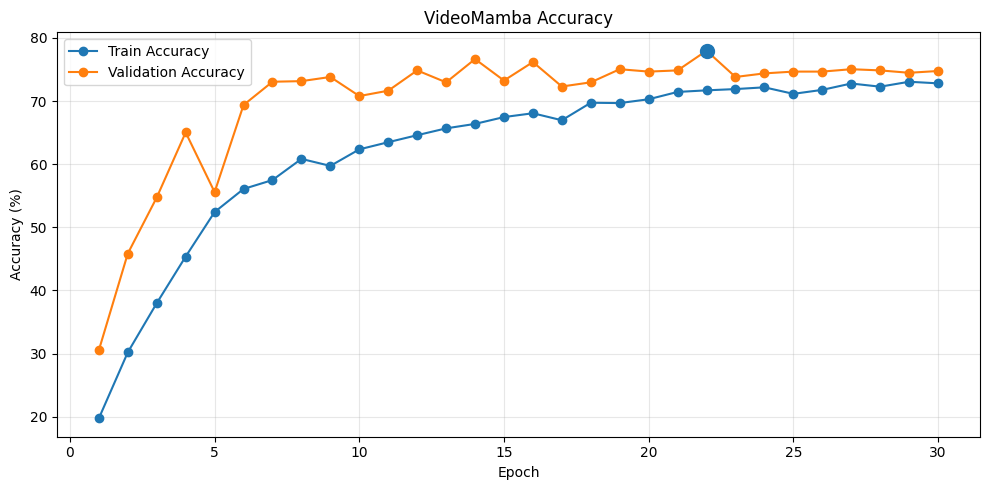

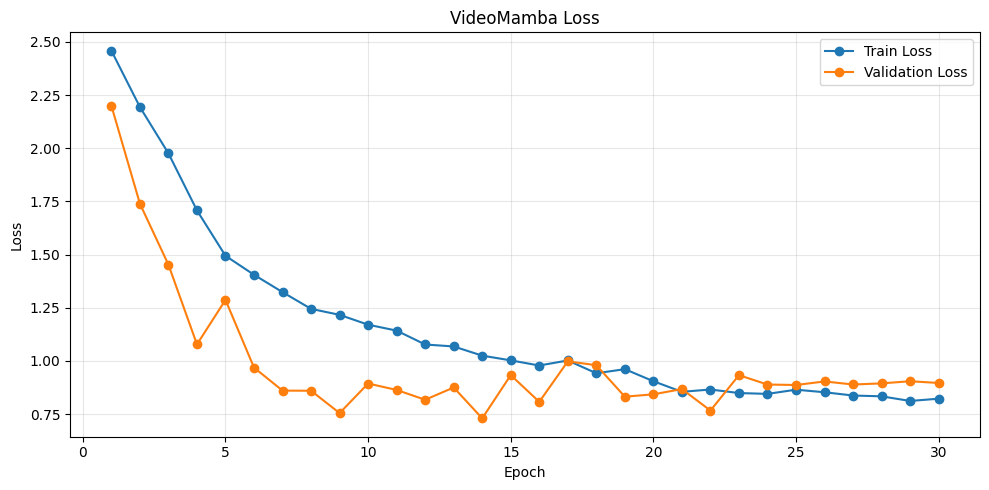

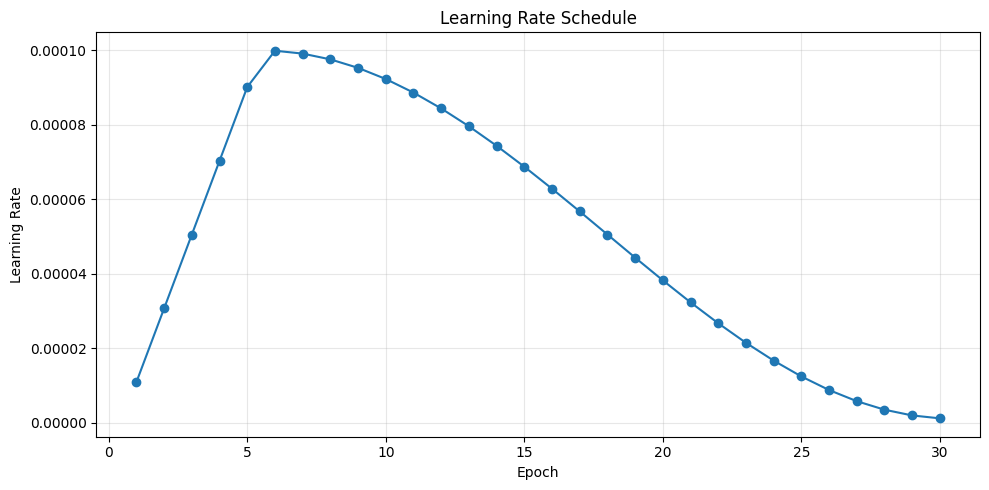

In [15]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = os.path.join(OUTPUT_DIR, 'log.txt')
if not os.path.isfile(LOG_PATH):
    raise FileNotFoundError(LOG_PATH)

rows = []
with open(LOG_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            record = json.loads(line)
            if 'epoch' in record:
                rows.append(record)
        except json.JSONDecodeError:
            pass
if not rows:
    raise RuntimeError('No epoch records in log.txt')

df = pd.DataFrame(rows)
df['Epoch'] = df['epoch'] + 1
if 'train_class_acc' in df: df['Train Accuracy (%)'] = df['train_class_acc'] * 100
if 'val_acc1' in df: df['Val Accuracy (%)'] = df['val_acc1']
if 'train_loss' in df: df['Train Loss'] = df['train_loss']
if 'val_loss' in df: df['Val Loss'] = df['val_loss']
if 'train_lr' in df: df['Learning Rate'] = df['train_lr']

best_idx = df['Val Accuracy (%)'].idxmax()
print('=' * 70)
print('TRAINING SUMMARY')
print('=' * 70)
print('Epochs recorded:', len(df))
print('Best epoch     :', int(df.loc[best_idx, 'Epoch']))
print(f"Best val acc   : {df.loc[best_idx, 'Val Accuracy (%)']:.2f}%")
print(f"Final train acc: {df.iloc[-1]['Train Accuracy (%)']:.2f}%")
print(f"Final val acc  : {df.iloc[-1]['Val Accuracy (%)']:.2f}%")

show_cols = [c for c in ['Epoch','Train Loss','Train Accuracy (%)','Val Loss','Val Accuracy (%)','Learning Rate'] if c in df]
display(df[show_cols].round(4))

plt.figure(figsize=(10,5))
plt.plot(df['Epoch'], df['Train Accuracy (%)'], marker='o', label='Train Accuracy')
plt.plot(df['Epoch'], df['Val Accuracy (%)'], marker='o', label='Validation Accuracy')
plt.scatter(df.loc[best_idx,'Epoch'], df.loc[best_idx,'Val Accuracy (%)'], s=100, zorder=5)
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('VideoMamba Accuracy')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(df['Epoch'], df['Train Loss'], marker='o', label='Train Loss')
plt.plot(df['Epoch'], df['Val Loss'], marker='o', label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('VideoMamba Loss')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

if 'Learning Rate' in df:
    plt.figure(figsize=(10,5))
    plt.plot(df['Epoch'], df['Learning Rate'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.title('Learning Rate Schedule')
    plt.grid(alpha=.3); plt.tight_layout(); plt.show()


## CELL 13: Single-view metrics và confusion matrix

Center temporal window + center crop, đọc trực tiếp `[t_start, t_end]` từ raw AVI.


Use checkpoint: False
Checkpoint number: 0
[OK] Loaded: /kaggle/working/videomamba_ipn_direct_224_ddp2_fp32_v2/checkpoint-best.pth
[OK] FP32 inference
Test samples: 622


Test FP32:   0%|          | 0/622 [00:00<?, ?it/s]


TEST RESULTS — SINGLE VIEW
Accuracy          : 0.7797
Balanced Accuracy : 0.6803
Macro F1          : 0.6839
Weighted F1       : 0.7738

                                     precision    recall  f1-score   support

                   D0X - No gesture     0.8629    0.9145    0.8880       117
     B0A - Pointing with one finger     0.8450    0.9008    0.8720       121
    B0B - Pointing with two fingers     0.8824    0.8750    0.8787       120
        G01 - Click with one finger     0.3810    0.3333    0.3556        24
       G02 - Click with two fingers     0.3333    0.1250    0.1818        24
                     G03 - Throw up     0.7391    0.7083    0.7234        24
                   G04 - Throw down     0.7778    0.8750    0.8235        24
                   G05 - Throw left     1.0000    0.7500    0.8571        24
                  G06 - Throw right     0.8571    0.7500    0.8000        24
                   G07 - Open twice     0.8421    0.6667    0.7442        24
 G08 - Double c

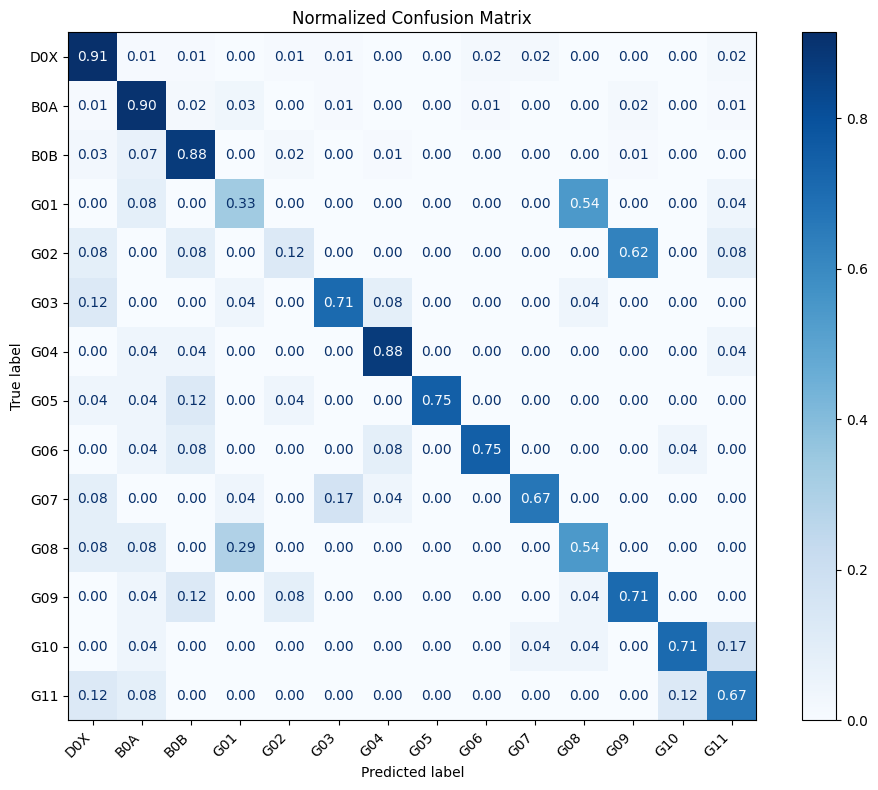

[OK] Saved: /kaggle/working/videomamba_ipn_direct_224_ddp2_fp32_v2/normalized_confusion_matrix.png


In [16]:
# ============================================================
# CELL 13 — Test metrics + Normalized Confusion Matrix
# checkpoint-best.pth | FP32 | no AMP
# ============================================================

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from decord import VideoReader, cpu
from torchvision import transforms
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

# ------------------------------------------------------------
# Import VideoMamba
# ------------------------------------------------------------

sys.path.insert(
    0,
    '/kaggle/working/VideoMamba/videomamba/video_sm'
)

from models import videomamba_tiny


# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

CLASS_CODES = [
    'D0X',
    'B0A',
    'B0B',
    'G01',
    'G02',
    'G03',
    'G04',
    'G05',
    'G06',
    'G07',
    'G08',
    'G09',
    'G10',
    'G11',
]

CLASS_NAMES = [
    'D0X - No gesture',
    'B0A - Pointing with one finger',
    'B0B - Pointing with two fingers',
    'G01 - Click with one finger',
    'G02 - Click with two fingers',
    'G03 - Throw up',
    'G04 - Throw down',
    'G05 - Throw left',
    'G06 - Throw right',
    'G07 - Open twice',
    'G08 - Double click with one finger',
    'G09 - Double click with two fingers',
    'G10 - Zoom in',
    'G11 - Zoom out',
]


# ------------------------------------------------------------
# Sample 16 frames from one annotated gesture segment
# ------------------------------------------------------------

def sample_segment_indices(
    total_frames,
    t_start_1b,
    t_end_1b,
    num_frames=16,
    sampling_rate=2,
):
    start = max(
        0,
        int(t_start_1b) - 1
    )

    end = min(
        total_frames,
        int(t_end_1b)
    )

    seg_len = end - start

    if seg_len <= 0:
        raise ValueError('Empty segment')

    span = (
        num_frames
        * sampling_rate
    )

    if seg_len >= span:

        local_start = (
            seg_len - span
        ) // 2

        idx = np.arange(
            local_start,
            local_start + span,
            sampling_rate,
            dtype=np.int64,
        )

    else:

        idx = np.linspace(
            0,
            seg_len - 1,
            num_frames,
        ).round().astype(np.int64)

    return idx + start


# ------------------------------------------------------------
# Load checkpoint-best
# ------------------------------------------------------------

device = torch.device('cuda:0')

BEST_CHECKPOINT = os.path.join(
    OUTPUT_DIR,
    'checkpoint-best.pth'
)

assert os.path.isfile(
    BEST_CHECKPOINT
), f'Missing: {BEST_CHECKPOINT}'


model = videomamba_tiny(
    pretrained=False,
    img_size=224,
    num_frames=16,
    kernel_size=1,
    num_classes=14,
)

try:
    checkpoint = torch.load(
        BEST_CHECKPOINT,
        map_location='cpu',
        weights_only=False,
    )

except TypeError:
    checkpoint = torch.load(
        BEST_CHECKPOINT,
        map_location='cpu',
    )


model.load_state_dict(
    checkpoint['model'],
    strict=True,
)

model = (
    model
    .float()
    .to(device)
    .eval()
)

print('[OK] Loaded:', BEST_CHECKPOINT)
print('[OK] FP32 inference')


# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225],
    ),
])


# ------------------------------------------------------------
# Load TEST set
# ------------------------------------------------------------

test_frame = pd.read_csv(
    os.path.join(
        DATA_ROOT,
        'test.csv'
    ),
    sep=r'\s+',
    header=None,
    names=[
        'path',
        'label',
        't_start',
        't_end',
        'uid',
    ],
    engine='python',
)

print(
    'Test samples:',
    len(test_frame)
)


# ------------------------------------------------------------
# Inference
# ------------------------------------------------------------

y_true = []
y_pred = []

with torch.inference_mode():

    for row in tqdm(
        test_frame.itertuples(
            index=False
        ),
        total=len(test_frame),
        desc='Test FP32',
    ):

        reader = VideoReader(
            row.path,
            num_threads=1,
            ctx=cpu(0),
        )

        idx = sample_segment_indices(
            len(reader),
            row.t_start,
            row.t_end,
        )

        frames = (
            reader
            .get_batch(idx)
            .asnumpy()
        )

        tensor = torch.stack([
            transform(frame)
            for frame in frames
        ])

        # [T,C,H,W]
        # ->
        # [1,C,T,H,W]

        tensor = (
            tensor
            .permute(1, 0, 2, 3)
            .unsqueeze(0)
            .to(
                device,
                dtype=torch.float32,
            )
        )

        logits = model(tensor)

        # NaN / Inf protection
        if not torch.isfinite(
            logits
        ).all():

            raise FloatingPointError(
                f'Non-finite logits '
                f'for uid={row.uid}'
            )

        pred = int(
            logits
            .argmax(dim=1)
            .item()
        )

        y_true.append(
            int(row.label)
        )

        y_pred.append(pred)


# ============================================================
# Metrics
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred,
)

balanced_acc = (
    balanced_accuracy_score(
        y_true,
        y_pred,
    )
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0,
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0,
)


print()
print('=' * 55)
print('TEST RESULTS — SINGLE VIEW')
print('=' * 55)

print(
    f'Accuracy          : '
    f'{accuracy:.4f}'
)

print(
    f'Balanced Accuracy : '
    f'{balanced_acc:.4f}'
)

print(
    f'Macro F1          : '
    f'{macro_f1:.4f}'
)

print(
    f'Weighted F1       : '
    f'{weighted_f1:.4f}'
)

print()


# ------------------------------------------------------------
# Precision / Recall / F1 per class
# ------------------------------------------------------------

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(14)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)


# ============================================================
# Normalized Confusion Matrix
# ============================================================

cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(14)),
    normalize='true',
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_CODES,
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='.2f',
    colorbar=True,
)

ax.set_title(
    'Normalized Confusion Matrix'
)

ax.set_xlabel(
    'Predicted label'
)

ax.set_ylabel(
    'True label'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()


CONFUSION_PATH = os.path.join(
    OUTPUT_DIR,
    'normalized_confusion_matrix.png'
)

plt.savefig(
    CONFUSION_PATH,
    dpi=250,
    bbox_inches='tight',
)

plt.show()


print(
    '[OK] Saved:',
    CONFUSION_PATH
)

## CELL 14: Demo inference trên một gesture segment thật thuộc `test.csv`


In [17]:
# ============================================================
# CELL 14 — Demo inference
# FP32 | checkpoint-best.pth
# ============================================================

import os
import torch

from decord import VideoReader, cpu


sample_row = test_frame.sample(
    1,
    random_state=SEED
).iloc[0]


# ------------------------------------------------------------
# Read sample
# ------------------------------------------------------------

reader = VideoReader(
    sample_row['path'],
    num_threads=1,
    ctx=cpu(0)
)

idx = sample_segment_indices(
    len(reader),
    sample_row['t_start'],
    sample_row['t_end']
)

frames = reader.get_batch(idx).asnumpy()


# ------------------------------------------------------------
# Preprocess
# ------------------------------------------------------------

sample_tensor = torch.stack([
    transform(frame)
    for frame in frames
])

sample_tensor = (
    sample_tensor
    .permute(1, 0, 2, 3)
    .unsqueeze(0)
    .to(
        device,
        dtype=torch.float32
    )
)


# ------------------------------------------------------------
# FP32 inference — no AMP
# ------------------------------------------------------------

with torch.inference_mode():
    logits = model(
        sample_tensor
    )


# Kiểm tra NaN / Inf
if not torch.isfinite(logits).all():
    raise FloatingPointError(
        f'Non-finite logits for uid={sample_row.uid}'
    )


probabilities = torch.softmax(
    logits,
    dim=1
)[0]


if not torch.isfinite(probabilities).all():
    raise FloatingPointError(
        f'Non-finite probabilities for uid={sample_row.uid}'
    )


# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

true_id = int(
    sample_row['label']
)

predicted_id = int(
    probabilities.argmax().item()
)

confidence = float(
    probabilities[
        predicted_id
    ].item()
)


print(
    'Raw video:  ',
    os.path.basename(
        sample_row['path']
    )
)

print(
    f"Segment:     "
    f"{int(sample_row['t_start'])}.."
    f"{int(sample_row['t_end'])} | "
    f"uid={int(sample_row['uid'])}"
)

print(
    'True:        ',
    CLASS_NAMES[true_id]
)

print(
    'Prediction:  ',
    CLASS_NAMES[predicted_id]
)

print(
    f'Confidence:   {confidence:.2%}'
)

print(
    'Precision:    FP32'
)

Raw video:   4CM11_10_R_#54.avi
Segment:     2273..2531 | uid=2488
True:         D0X - No gesture
Prediction:   D0X - No gesture
Confidence:   44.03%
Precision:    FP32
